# Comparing inference methods: NUTS, SVI, Pathfinder, and MCLMC with `numpyro_forecast`

One advantage of writing a forecasting model once is that you can fit it with different inference engines without touching the model code. In this notebook we take the weekly BART ridership model from the [univariate forecasting example](forecasting_univariate.html) (a random-walk local level, Fourier seasonality, and a Student-T likelihood) and fit it four ways: with **NUTS** (Markov chain Monte Carlo), with **SVI** (stochastic variational inference, using a custom [optax](https://optax.readthedocs.io/en/latest/) optimizer), with **multi-path Pathfinder** (quasi-Newton variational inference run over several parallel L-BFGS paths, from [BlackJAX](https://blackjax-devs.github.io/blackjax/)), and with **MCLMC** (microcanonical Langevin Monte Carlo, a BlackJAX sampler that plugs into the same MCMC entry point through a kernel adapter).

Every engine ends in the same shape: a dict of posterior samples with a leading sample axis, either read straight off an `MCMC` run (`mcmc.get_samples()`) or drawn from a fitted variational approximation (`draw_posterior`, `multipathfinder_samples`). A single `to_datatree` call then turns any of them into an ArviZ `DataTree` holding both the in-sample posterior predictive and the forecast over the test horizon, which powers the plots and the evaluation alike. We compare the four engines on the continuous ranked probability score (CRPS) over the training and test windows, and on wall-clock time.

## Prepare notebook

In [1]:
from collections.abc import Mapping
from time import perf_counter

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import optax
import pandas as pd
import xarray as xr
from jax import random
from numpyro.diagnostics import effective_sample_size
from numpyro.infer import MCMC, NUTS, SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.reparam import LocScaleReparam
from numpyro.optim import optax_to_numpyro

from numpyro_forecast import (
    Horizon,
    draw_posterior,
    eval_crps,
    innovations,
    predict,
    time_reparam,
    to_datatree,
)
from numpyro_forecast.contrib.blackjax import (
    BlackjaxMCLMCKernel,
    fit_multipathfinder,
    multipathfinder_samples,
)
from numpyro_forecast.datasets import load_bart_weekly
from numpyro_forecast.features import fourier_features
from numpyro_forecast.typing import Array, ForecastModel

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

## Read data

We work with total weekly BART ridership on the log scale, exactly as in the univariate example. Throughout the package, time lives at axis `-2` and the observation dimension at axis `-1`, so the series has shape `(weeks, 1)`.

In [2]:
data = load_bart_weekly()  # (weeks, 1), log scale
duration = data.shape[0]
print("data shape:", data.shape)

data shape: (469, 1)


## Train-test split

We hold out the last `52` weeks (one full year) as the test set and train on the preceding `417` weeks, so the test window covers a complete seasonal cycle.

train: (417, 1) test: (52, 1)


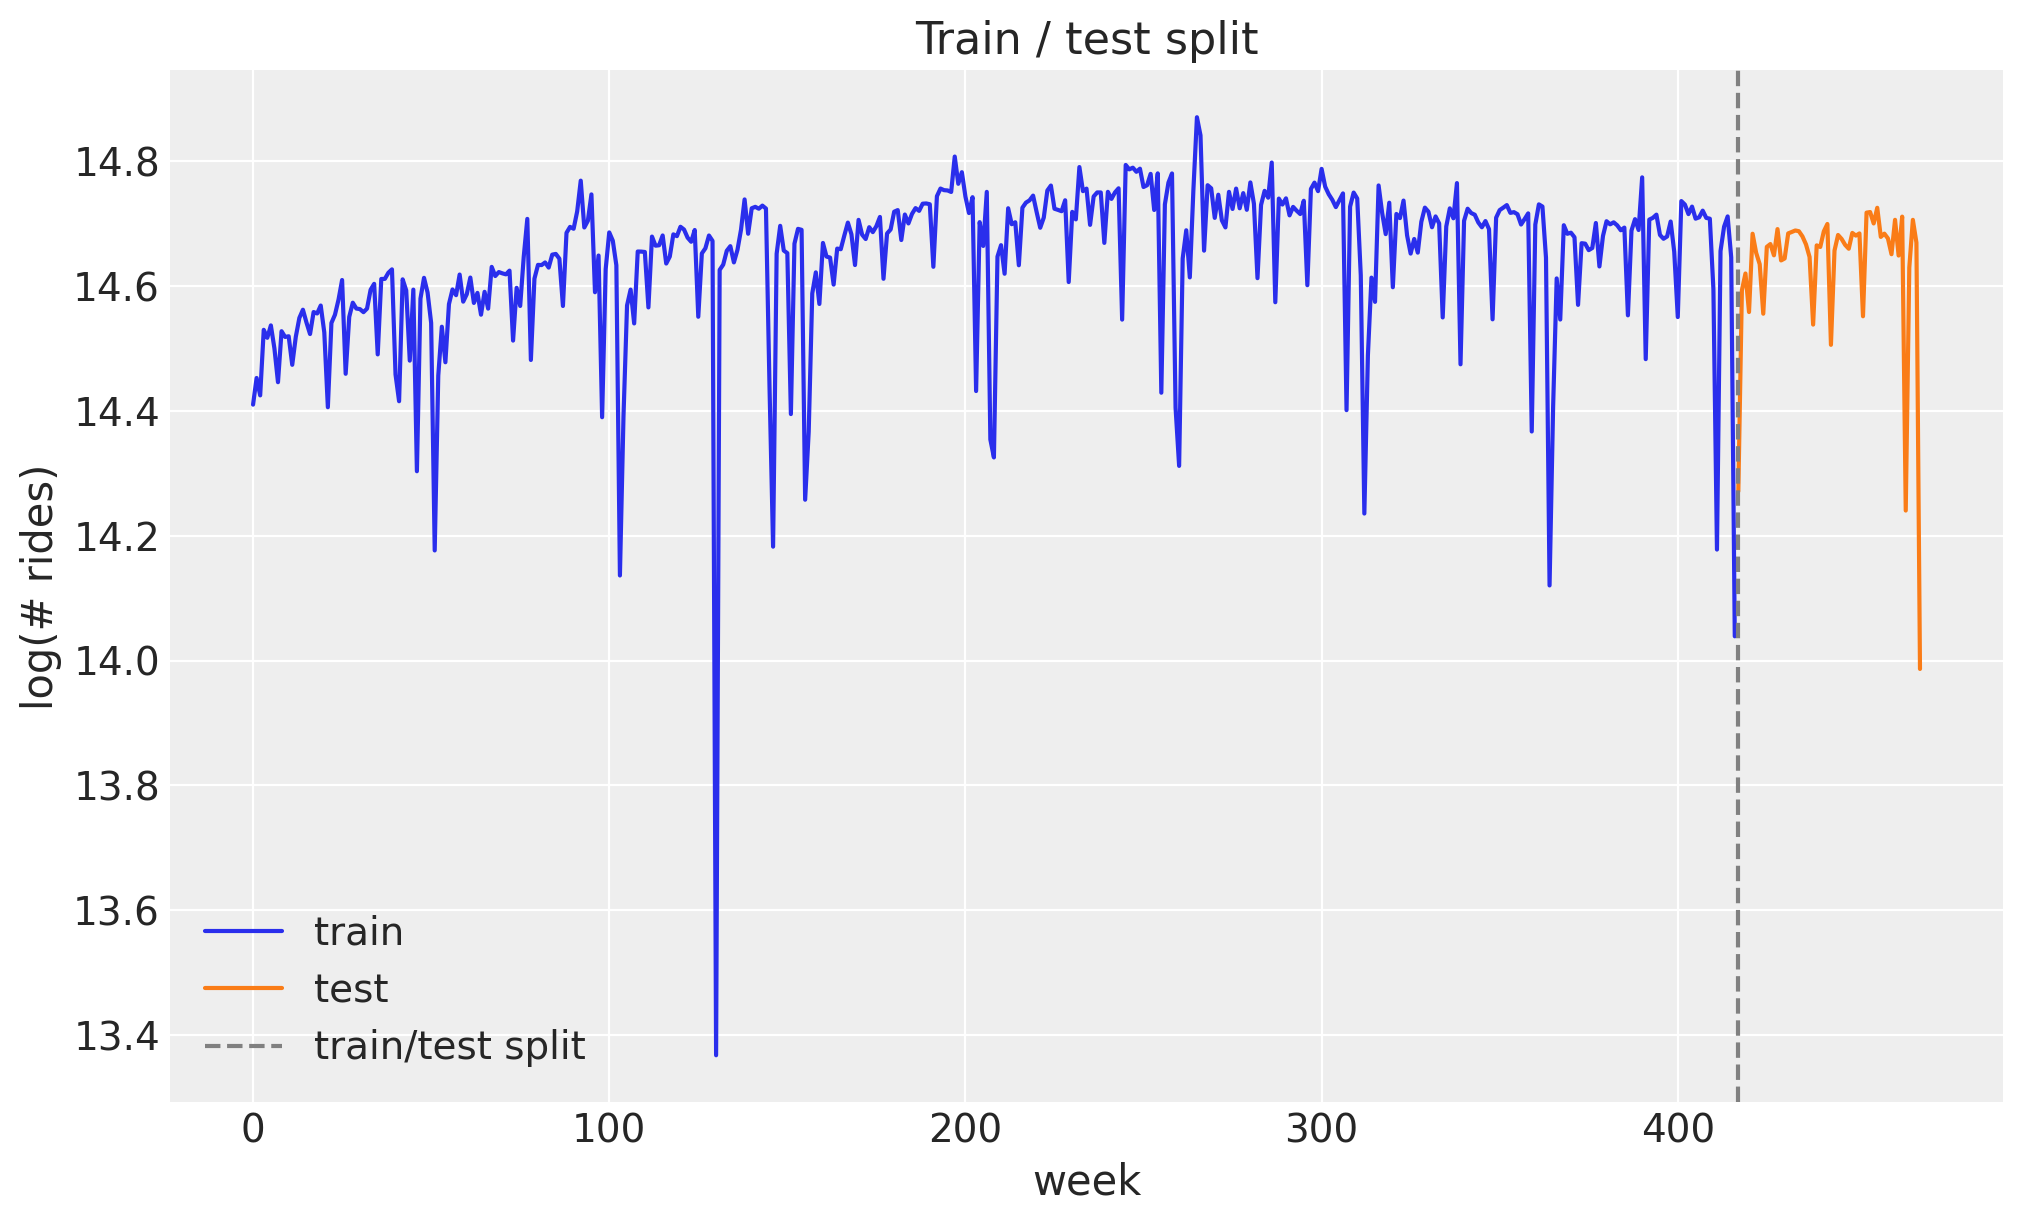

In [3]:
T0 = 0
T2 = duration  # 469
T1 = T2 - 52  # 417: train / test split

y_train = data[T0:T1]
y_test = data[T1:T2]

time = np.arange(T2)
time_train = time[T0:T1]
time_test = time[T1:T2]
print("train:", y_train.shape, "test:", y_test.shape)

fig, ax = plt.subplots()
ax.plot(time_train, np.asarray(y_train[:, 0]), color="C0", label="train")
ax.plot(time_test, np.asarray(y_test[:, 0]), color="C1", label="test")
ax.axvline(T1, color="gray", ls="--", label="train/test split")
ax.legend()
ax.set(title="Train / test split", xlabel="week", ylabel="log(# rides)");

## Seasonal features

The annual cycle enters through a Fourier design matrix built with `fourier_features`: `26` harmonics (so `52` sine and cosine columns) at a period of `365.25 / 7` weeks.

In [4]:
num_terms = 26
covariates = fourier_features(duration, period=365.25 / 7, num_terms=num_terms)
covariates_train = covariates[T0:T1]
print("covariates shape:", covariates.shape)

covariates shape: (469, 52)


## Model specification

The model is the same *local level with seasonality* as in the [univariate forecasting example](forecasting_univariate.html): a global bias, a random-walk level, and a Fourier regression for the annual cycle, with a heavy-tailed Student-T likelihood to absorb outlier weeks. See that notebook for the full mathematical specification, the priors, and a rendering of the model graph. Here we only restate the code, written once as a plain `(covariates, data=None)` function, so all four inference engines below consume exactly the same object.

In [5]:
def univariate_model(covariates: Array, data: Array | None = None) -> None:
    """Local level + Fourier regression with Student-T observations."""
    h = Horizon.from_data(covariates, data)
    num_features = covariates.shape[-1]

    bias = numpyro.sample("bias", dist.Normal(0.0, 10.0))
    weight = numpyro.sample("weight", dist.Normal(0.0, 0.1).expand([num_features]).to_event(1))
    drift_scale = numpyro.sample("drift_scale", dist.LogNormal(-20.0, 5.0))
    nu = numpyro.sample("nu", dist.Gamma(10.0, 2.0))
    sigma = numpyro.sample("sigma", dist.LogNormal(-5.0, 5.0))
    centered = numpyro.sample("centered", dist.Uniform(0.0, 1.0))

    drift = innovations(
        h,
        "drift",
        lambda: dist.Normal(0.0, drift_scale),
        reparam=LocScaleReparam(centered=centered),
    )
    level = jnp.cumsum(drift, axis=-2)
    regression = (weight * covariates).sum(axis=-1, keepdims=True)
    prediction = level + bias + regression

    predict(h, dist.StudentT(df=nu, loc=0.0, scale=sigma), prediction)

## Inference

We now fit the same model four times, once per inference engine, using plain NumPyro (`MCMC`/`SVI`) or BlackJAX entry points directly against `univariate_model`; nothing about the model changes, only how we draw a posterior from it. In brief:

- **NUTS** (the No-U-Turn Sampler) is gradient-based Markov chain Monte Carlo. It draws asymptotically exact samples from the posterior, which makes it our reference here, usually at the highest computational cost of the four, though the discussion below shows that ranking is not absolute.
- **SVI** (stochastic variational inference) turns inference into optimization: it fits the parameters of an approximating guide distribution (here `AutoNormal`, a diagonal Gaussian) by maximizing the evidence lower bound (ELBO). It is much faster than MCMC, and its accuracy is bounded by how well the guide family can match the true posterior.
- **Multi-path Pathfinder** is quasi-Newton variational inference, run several times over. Each of several independent L-BFGS paths (vectorized under `vmap`) recycles its own optimization trajectory into a normal approximation and an ELBO estimate; instead of keeping only the best-ELBO path, all of them are kept and combined when the draws are taken, either by Pareto-smoothed importance sampling (PSIS) over the pooled draws or by weighting whole paths by their ELBO, with the `pareto_k` diagnostic deciding which of the two is trustworthy. It is often used for fast approximate posteriors or to initialize MCMC.
- **MCLMC** (microcanonical Langevin Monte Carlo) is MCMC of a different flavor: it simulates energy-preserving isokinetic dynamics with stochastic momentum refreshment and skips the Metropolis accept/reject correction entirely. Every draw costs a fixed two gradient evaluations, far below the cost of a NUTS trajectory, in exchange for a small step-size-controlled bias in the stationary distribution.

Each engine below hands us either raw posterior samples (`mcmc.get_samples()` for NUTS and MCLMC) or a fitted guide/approximation that a small drawing function turns into samples of the same shape (`draw_posterior` for SVI, `multipathfinder_samples` for Pathfinder), and `to_datatree` accepts either form, so the export below is one call whichever engine produced the posterior.

### NUTS

We run `4` chains in parallel with `2_000` warmup steps and `1_000` posterior draws each. The posterior includes one drift increment per training week (417 of them), so this is an expensive fit: of the four engines here, only the eight-path Pathfinder run below takes longer.

In [6]:
rng_key, rng_subkey = random.split(rng_key)

start = perf_counter()
nuts_mcmc = MCMC(
    NUTS(univariate_model),
    num_warmup=2_000,
    num_samples=1_000,
    num_chains=4,
    chain_method="parallel",
    progress_bar=False,
)
nuts_mcmc.run(rng_subkey, covariates_train, y_train, extra_fields=("num_steps",))
nuts_samples = nuts_mcmc.get_samples()
jax.block_until_ready(nuts_samples)
nuts_seconds = perf_counter() - start
print(f"NUTS: 4 chains x 1_000 draws in {nuts_seconds:.1f}s")

NUTS: 4 chains x 1_000 draws in 40.7s


### NUTS with time-axis reparameterization

The `417` drift increments are the expensive part of this posterior, and not only because there are many of them: the level is their cumulative sum, so the data constrain sums of neighboring increments far more tightly than any single one, and the posterior over the block is a long thin ellipse along the time axis. `time_reparam` wraps the model with a `numpyro.handlers.reparam` handler that rotates every in-sample latent under the `time` plate into an orthonormal basis, here the discrete cosine basis (`"dct"`; `"haar"` picks a wavelet basis instead). The rotation leaves the log density unchanged and only changes the coordinates inference sees: the sampler now draws the auxiliary site `drift_decentered_dct`, and both `drift_decentered` and `drift` become deterministic sites recomputed from it. We build the wrapped model once (it is a static argument of the jit-compiled drivers, so wrapping inside a loop would recompile) and reuse it in every cell below that needs it, including the ArviZ export.

The run uses the same `MCMC(NUTS(...))` configuration as above. We collect `num_steps`, the number of leapfrog steps per iteration, for both runs and compare wall time, mean leapfrog steps per draw, and the smallest bulk effective sample size over the `417` drift increments, computed with `numpyro.diagnostics.effective_sample_size` from the chain-grouped samples.

In [7]:
univariate_model_dct = time_reparam(univariate_model, "dct")

rng_key, rng_subkey = random.split(rng_key)

start = perf_counter()
nuts_dct_mcmc = MCMC(
    NUTS(univariate_model_dct),
    num_warmup=2_000,
    num_samples=1_000,
    num_chains=4,
    chain_method="parallel",
    progress_bar=False,
)
nuts_dct_mcmc.run(rng_subkey, covariates_train, y_train, extra_fields=("num_steps",))
nuts_dct_samples = nuts_dct_mcmc.get_samples()
jax.block_until_ready(nuts_dct_samples)
nuts_dct_seconds = perf_counter() - start
print(f"NUTS + DCT: 4 chains x 1_000 draws in {nuts_dct_seconds:.1f}s")

NUTS + DCT: 4 chains x 1_000 draws in 56.9s


In [8]:
def nuts_report(mcmc: MCMC, seconds: float) -> dict[str, float]:
    """Wall time, mean leapfrog steps per draw, and min bulk ESS over ``drift`` for a run."""
    drift = mcmc.get_samples(group_by_chain=True)["drift"]
    return {
        "walltime (s)": seconds,
        "leapfrog / draw": float(mcmc.get_extra_fields()["num_steps"].mean()),
        "min ESS (drift)": float(effective_sample_size(drift).min()),
    }


nuts_comparison = pd.DataFrame(
    {
        "NUTS": nuts_report(nuts_mcmc, nuts_seconds),
        "NUTS + DCT": nuts_report(nuts_dct_mcmc, nuts_dct_seconds),
    }
).T
nuts_comparison.round(1)

,walltime (s),leapfrog / draw,min ESS (drift)
NUTS,40.7,446.4,45.8
NUTS + DCT,56.9,314.4,558.9


### SVI

NumPyro's `SVI` expects a NumPyro optimizer, so any optax `GradientTransformation` needs one line of glue, `numpyro.optim.optax_to_numpyro`, before it can be passed in. We use that to run a custom optimizer built from two pieces:

- A **one-cycle** learning-rate schedule (`optax.linear_onecycle_schedule`): a linear warmup to a peak followed by a long annealing phase. The warmup lets the optimizer pass through a much higher mid-run learning rate than a fixed setting could tolerate, and the final annealing polishes the optimum.
- **Reduce-on-plateau** (`optax.contrib.reduce_on_plateau`): an adaptive safeguard that scales the updates down by `factor=0.8` whenever the ELBO, averaged over `accumulation_size=100` steps, stops improving for `patience=20` consecutive windows. NumPyro forwards the per-step ELBO value to the optimizer chain, which is exactly the signal this transformation monitors.

The univariate example needs `50_000` steps at a fixed `Adam(0.005)`; cycling up to a peak of `0.01` reaches a comparable ELBO in `20_000` steps, less than half the budget.

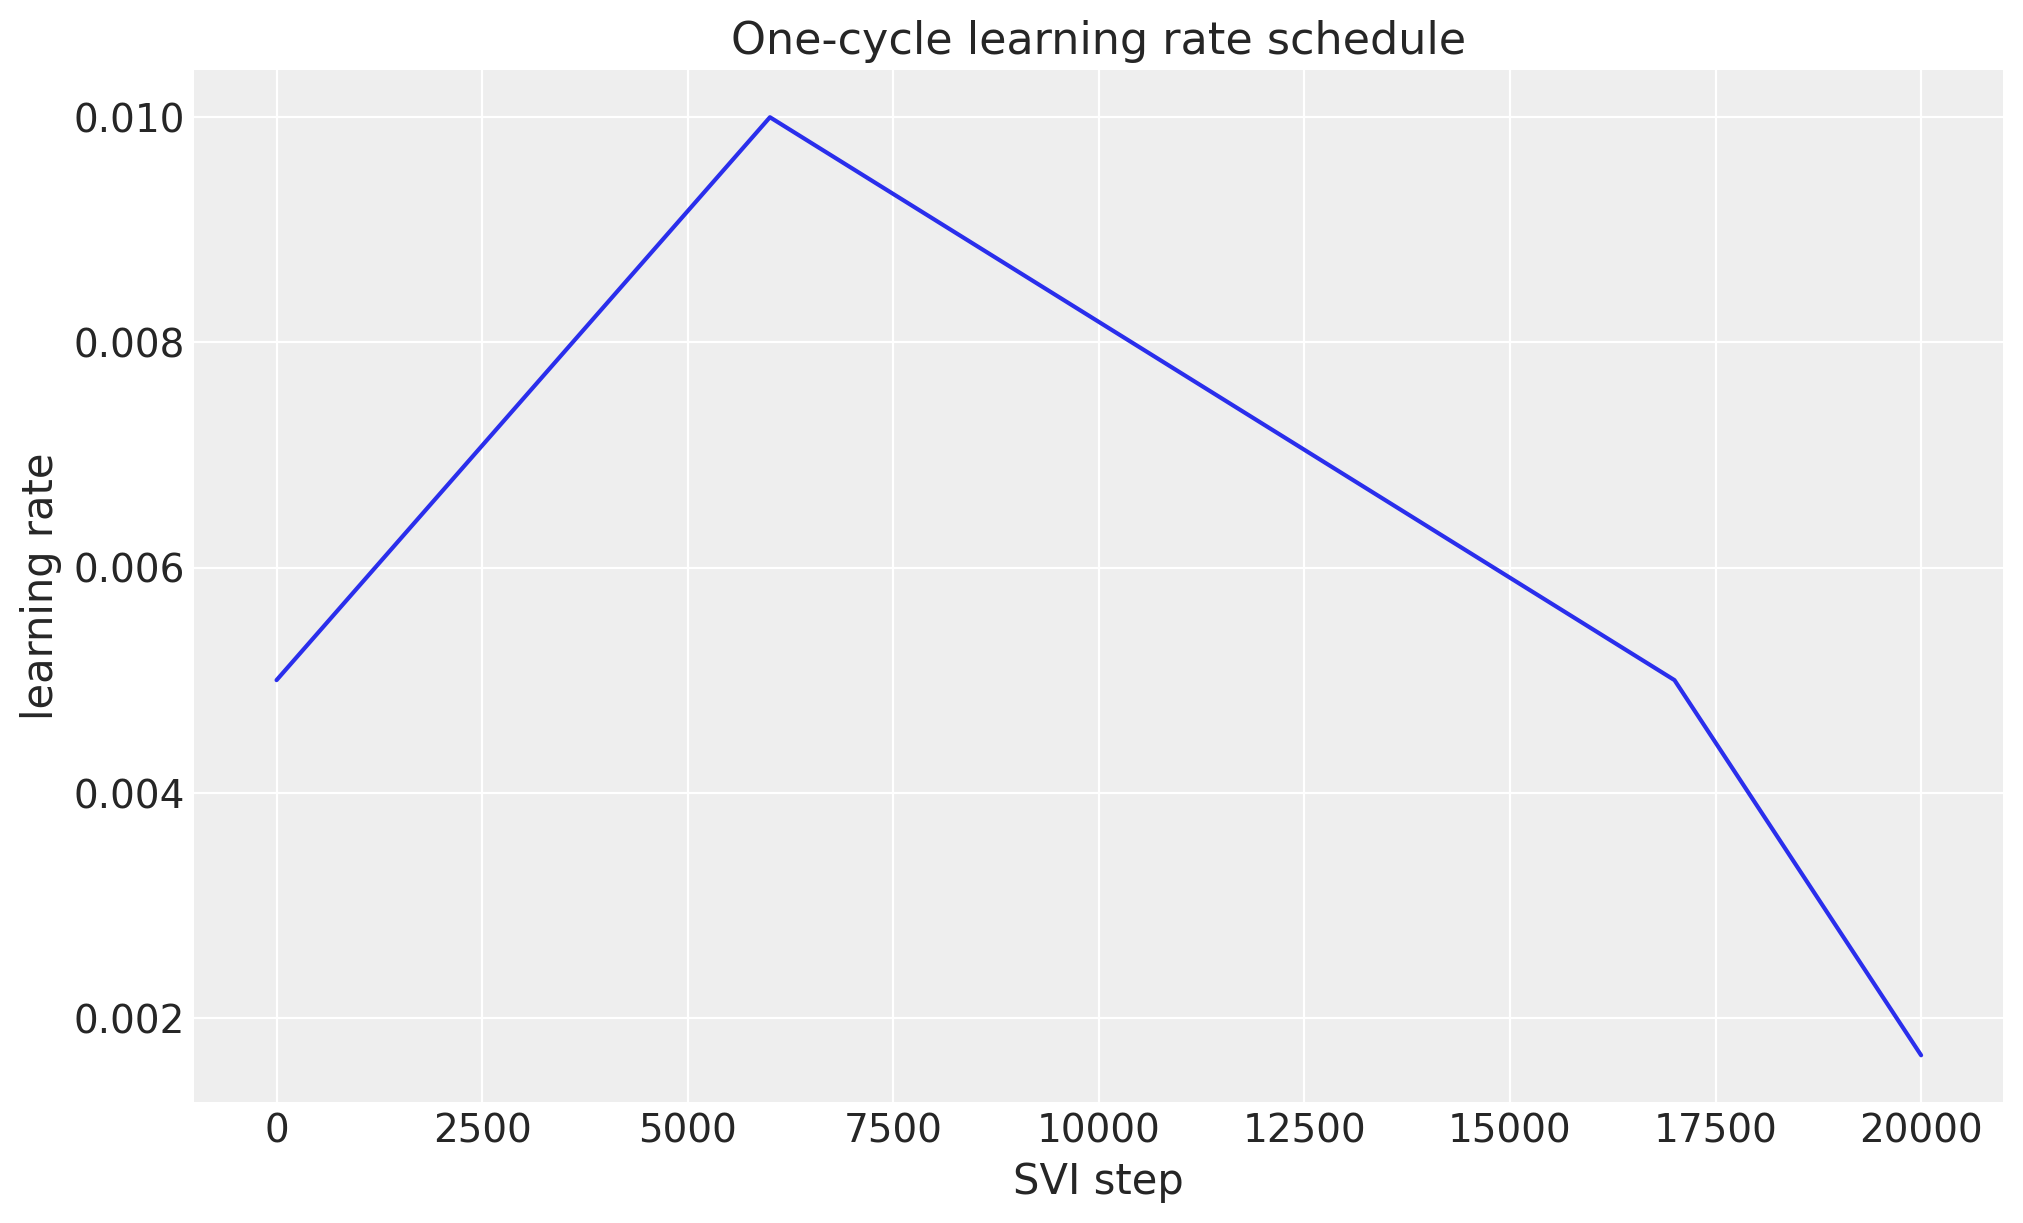

In [9]:
num_steps = 20_000

scheduler = optax.linear_onecycle_schedule(
    transition_steps=num_steps,
    peak_value=0.01,
    pct_start=0.3,
    pct_final=0.85,
    div_factor=2,
    final_div_factor=3,
)

optimizer = optax.chain(
    optax.adam(learning_rate=scheduler),
    optax.contrib.reduce_on_plateau(
        factor=0.8,
        patience=20,
        accumulation_size=100,
    ),
)
optim = optax_to_numpyro(optimizer)

fig, ax = plt.subplots()
ax.plot(np.asarray(jax.vmap(scheduler)(jnp.arange(num_steps))), color="C0")
ax.set(title="One-cycle learning rate schedule", xlabel="SVI step", ylabel="learning rate");

SVI: 20_000 steps in 5.2s


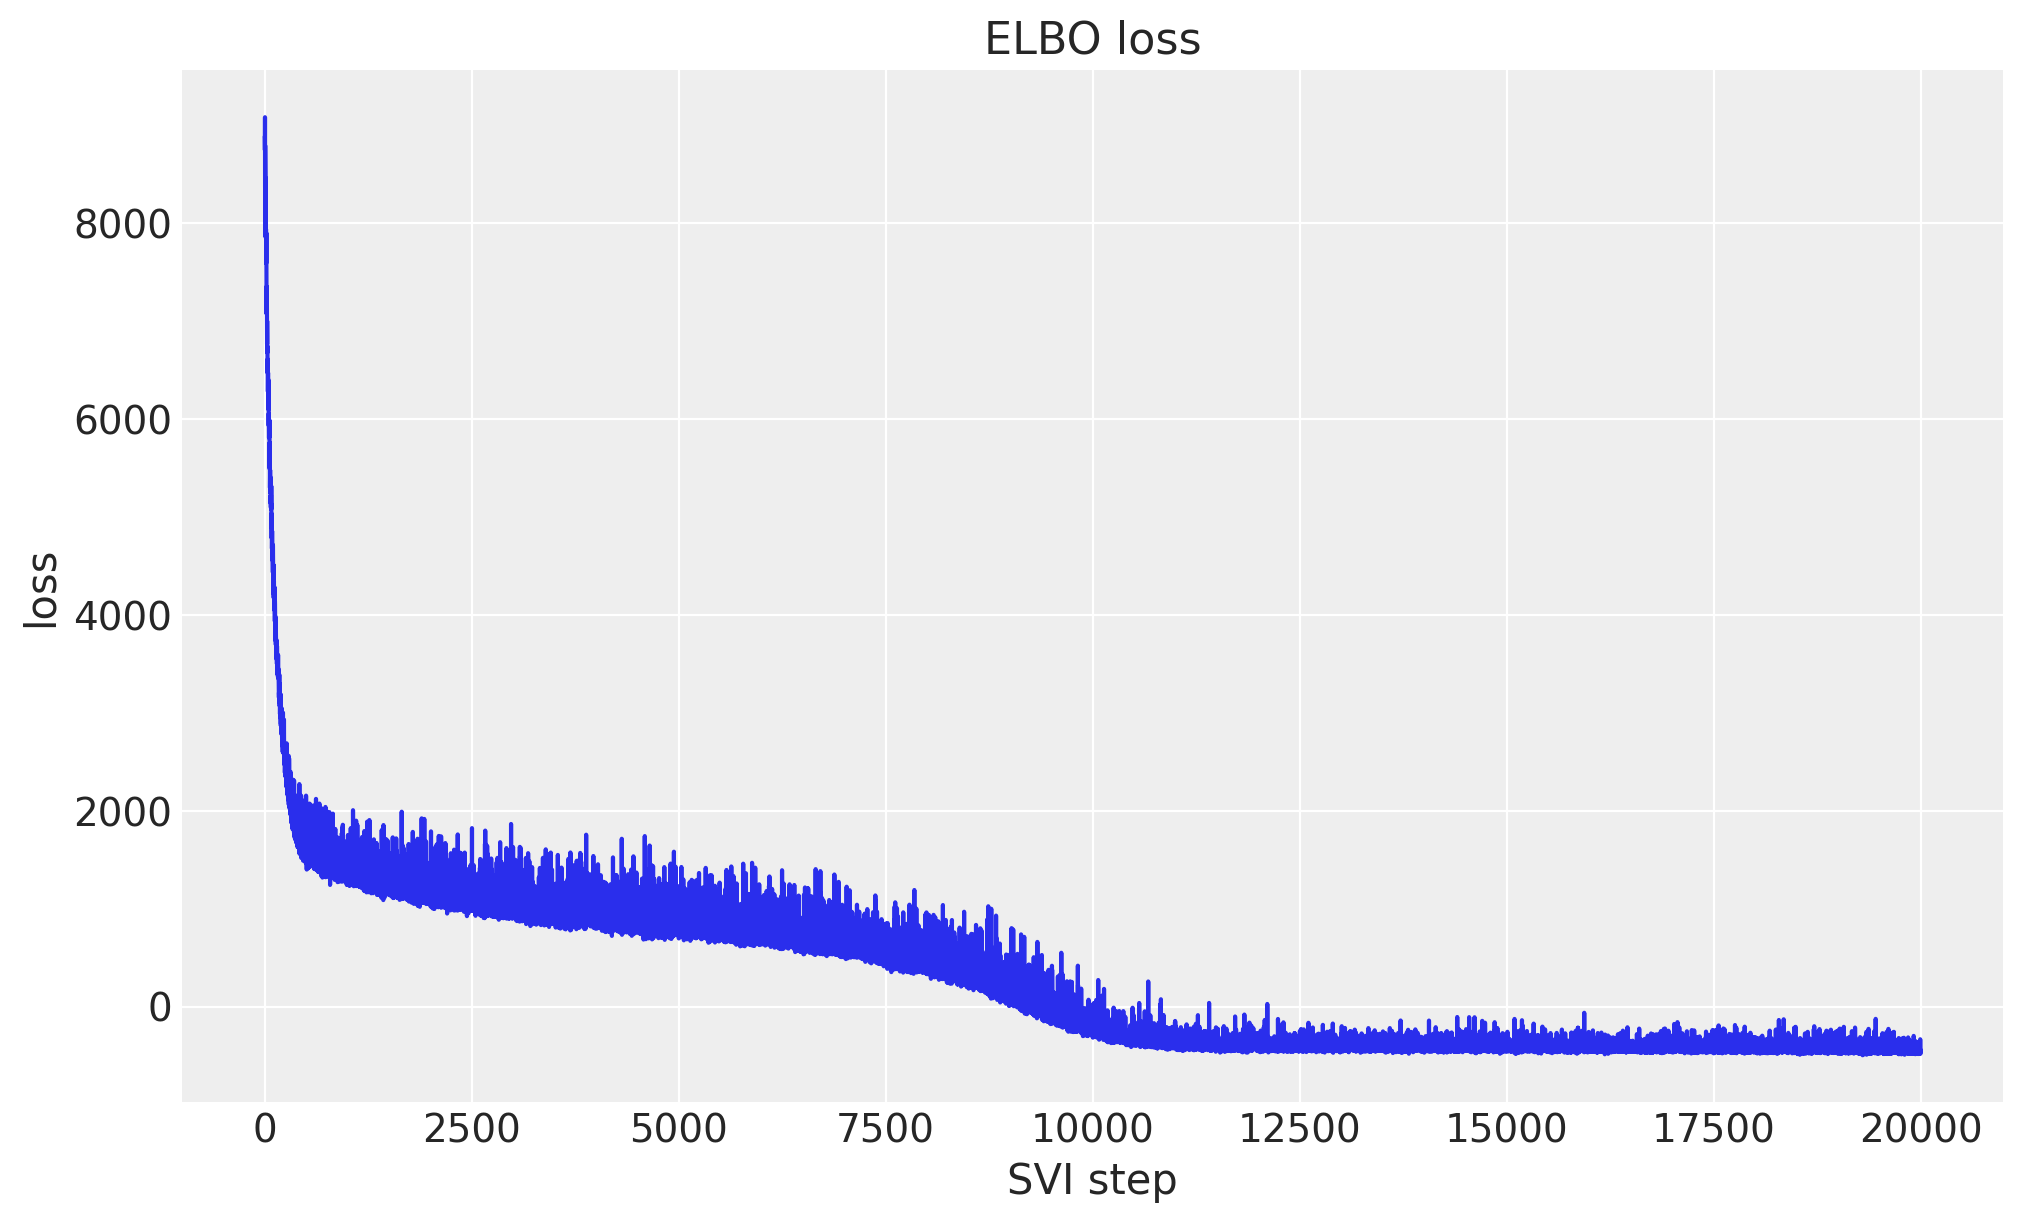

In [10]:
guide = AutoNormal(univariate_model)
svi = SVI(univariate_model, guide, optim, Trace_ELBO())

rng_key, rng_subkey = random.split(rng_key)

start = perf_counter()
svi_result = svi.run(rng_subkey, num_steps, covariates_train, y_train, progress_bar=False)
jax.block_until_ready(svi_result.losses)
svi_seconds = perf_counter() - start
print(f"SVI: {num_steps:_} steps in {svi_seconds:.1f}s")

fig, ax = plt.subplots()
ax.plot(svi_result.losses)
ax.set(title="ELBO loss", xlabel="SVI step", ylabel="loss");

`SVI.run` fits `guide`, but a guide by itself is not yet a set of posterior samples: `draw_posterior` draws `2_000` samples of the latent sites from the fitted `guide`/`params` pair, in the same leading-sample-axis shape `to_datatree` and `forecast` expect.

In [11]:
rng_key, rng_subkey = random.split(rng_key)
svi_posterior = draw_posterior(rng_subkey, guide, svi_result.params, 2_000)

### SVI with time-axis reparameterization

A diagonal-Gaussian guide is exactly the approximation that the long thin drift posterior defeats: `AutoNormal` has no off-diagonal terms with which to represent the coupling between neighboring increments, so it either shrinks every marginal to fit the ridge or overstates the joint uncertainty. In the DCT basis that coupling is largely gone, so the same guide family is fitted to a rotated posterior that is closer to diagonal. We keep the optimizer, the one-cycle schedule, and the `20_000` step budget of the baseline unchanged so that the two runs differ only in the coordinates the guide sees. `univariate_model_dct` is the model handed to `AutoNormal`, to `SVI`, and later to the export, and `draw_posterior` returns a posterior dict that now carries the sampled `drift_decentered_dct` alongside the deterministic `drift_decentered` and `drift`, which `to_datatree` and `forecast` consume unchanged.

SVI + DCT: 20_000 steps in 3.3s


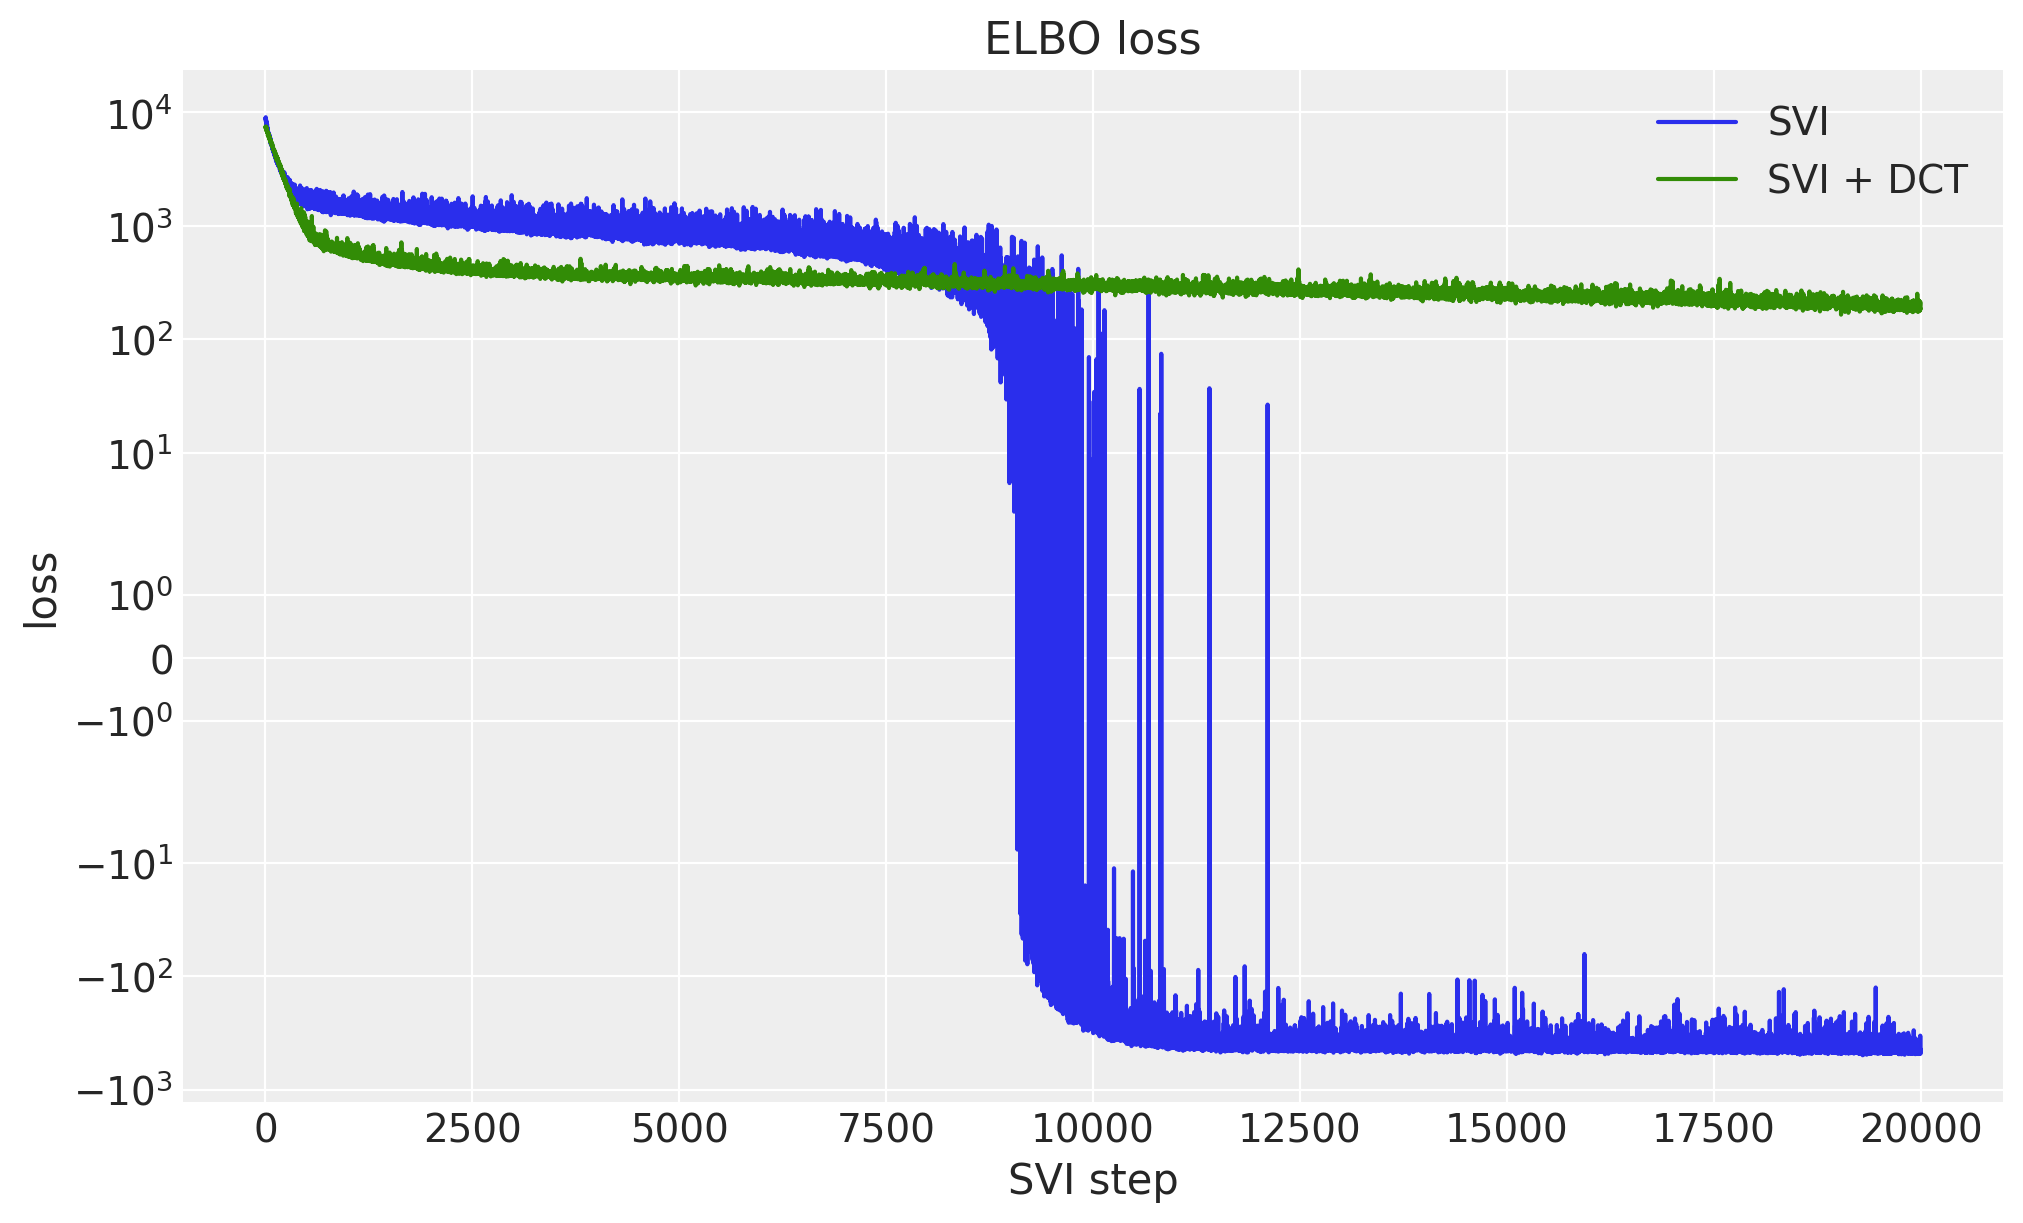

In [12]:
guide_dct = AutoNormal(univariate_model_dct)
svi_dct = SVI(univariate_model_dct, guide_dct, optim, Trace_ELBO())

rng_key, rng_subkey = random.split(rng_key)

start = perf_counter()
svi_dct_result = svi_dct.run(rng_subkey, num_steps, covariates_train, y_train, progress_bar=False)
jax.block_until_ready(svi_dct_result.losses)
svi_dct_seconds = perf_counter() - start
print(f"SVI + DCT: {num_steps:_} steps in {svi_dct_seconds:.1f}s")

fig, ax = plt.subplots()
ax.plot(svi_result.losses, color="C0", label="SVI")
ax.plot(svi_dct_result.losses, color="C2", label="SVI + DCT")
ax.set_yscale("symlog")
ax.legend()
ax.set(title="ELBO loss", xlabel="SVI step", ylabel="loss");

In [13]:
def svi_report(losses: Array, median: Mapping[str, Array]) -> dict[str, float]:
    """Report the final ELBO loss (mean over the last ``100`` steps) and scalar guide medians."""
    return {
        "final ELBO loss": float(jnp.mean(losses[-100:])),
        "bias": float(median["bias"]),
        "drift_scale": float(median["drift_scale"]),
        "centered": float(median["centered"]),
    }


svi_comparison = pd.DataFrame(
    {
        "SVI": svi_report(svi_result.losses, guide.median(svi_result.params)),
        "SVI + DCT": svi_report(svi_dct_result.losses, guide_dct.median(svi_dct_result.params)),
    }
).T
svi_comparison.round(4)

,final ELBO loss,bias,drift_scale,centered
SVI,-435.7541,14.5341,0.0014,0.0761
SVI + DCT,197.1361,5.6526,0.1576,0.7438


The two curves tell one story in two halves. Over the first few thousand steps the rotated run descends far faster, which is the geometric advantage the transform is meant to buy. It then settles into a different basin: its final ELBO loss is much worse than the baseline's, and the guide medians show why. The baseline puts the intercept in `bias` and learns a tiny `drift_scale`, while the DCT run leaves part of the intercept in the level itself, at the cost of a `drift_scale` two orders of magnitude larger, which inflates every increment's marginal and, through the cumulative sum, the whole in-sample band. The model's log density is unchanged by the rotation, so this is a property of the optimization path rather than of the objective: a learning-rate schedule tuned for the original coordinates does not transfer to the rotated ones, and the reparameterization has to be re-tuned rather than dropped in. The [univariate example](forecasting_univariate.html) runs the same comparison under a fixed `Adam(0.005)` for `50_000` steps, and there the DCT fit ends at the better ELBO. We keep the run here as it is and let the CRPS below record the consequence.

In [14]:
rng_key, rng_subkey = random.split(rng_key)
svi_dct_posterior = draw_posterior(rng_subkey, guide_dct, svi_dct_result.params, 2_000)

### Pathfinder

`fit_multipathfinder` lives in `numpyro_forecast.contrib.blackjax` and needs the optional BlackJAX backend (install it with `pip install "numpyro_forecast[blackjax]"`). It runs several independent L-BFGS paths toward the posterior mode, each inducing its own normal approximation and its own ELBO estimate, and keeps every one of them instead of returning only the best-ELBO path.

Three settings matter here. The first is `maxiter`, the L-BFGS iteration budget: the default (`30`) suits posteriors with a handful of parameters, but ours has one drift increment per training week and needs a few hundred iterations to approach the high-density region, so we set it to `500`. The second is `maxcor`, the L-BFGS history size: it caps the rank of the low-rank-plus-diagonal covariance correction at roughly twice its value, so the default of `10` gives a correction of rank about `20` on a posterior with roughly `474` parameters here, and we raise it to `50` to let the approximation capture more of that covariance structure. The third is `num_paths`, the number of independent L-BFGS paths: they run vectorized under `vmap`, so all eight share one compilation and advance together rather than one after another, and all of their approximations survive into the drawing step below rather than being discarded in favor of a single winner.

`num_elbo_samples` is the memory knob rather than a quality knob. The fit estimates an ELBO at every L-BFGS iterate of every path, so it materializes on the order of `num_paths * maxiter * num_elbo_samples * 474` numbers at once; we keep it at `100` so that the `maxiter=500` this posterior needs stays affordable on a laptop. It also sets the size of the pool that the fit-time `pareto_k` diagnostic printed below is computed over, which is a separate pool from the draws taken in the next cell.

This section also owns its own `PRNGKey`, split from a fixed seed rather than threaded through the notebook's running `rng_key`, so edits earlier in the notebook cannot reshuffle its random stream.

In [15]:
key_pathfinder_fit, key_pathfinder_draw = random.split(random.PRNGKey(seed=2_025))

start = perf_counter()
pathfinder_fit = fit_multipathfinder(
    key_pathfinder_fit,
    univariate_model,
    y_train,
    covariates_train,
    num_paths=8,
    num_elbo_samples=100,
    maxiter=500,
    maxcor=50,
)
pathfinder_seconds = perf_counter() - start

print("per-path ELBO:", [round(elbo, 1) for elbo in pathfinder_fit.elbos])
print(f"pareto_k: {pathfinder_fit.pareto_k:.2f}")
print(f"Pathfinder: {len(pathfinder_fit.elbos)} paths in {pathfinder_seconds:.1f}s")

per-path ELBO: [-1272.3, -741.4, -524.7, -597.5, -805.8, -1532.1, -497.5, -192.3]
pareto_k: 12.35
Pathfinder: 8 paths in 79.9s


/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_91376/3865784160.py:4: UserWarning: pareto_k=12.35 > 0.7: PSIS importance weights over the pooled draws are unreliable, so multipathfinder_samples(..., resample="auto") falls back to ELBO-weighted path sampling instead of PSIS resampling; increase num_paths/maxiter/maxcor or fall back to MCMC.
  pathfinder_fit = fit_multipathfinder(


`multipathfinder_samples` draws fresh samples from every path's fitted approximation on each call, `2_000` per path here, and then combines the `8` paths into the `2_000` returned draws. How it combines them is the `resample` argument. With `resample="psis"` all `8 * 2_000` fresh draws are pooled, scored both under the model and under the approximation that produced them, and importance-resampled with Pareto smoothing, which is the textbook multi-path Pathfinder estimator. With `resample="elbo"` each returned draw instead picks a whole path with probability proportional to `softmax` of the per-path ELBOs and takes one fresh draw from it, so a path that fits several hundred nats better than the rest simply takes over.

The default, `resample="auto"`, chooses between the two using the `pareto_k` printed above: PSIS when `pareto_k` is at most `0.7`, and ELBO-weighted path sampling otherwise. The gate matters because importance weights degenerate in high dimensions. On a posterior with hundreds of parameters the log ratio between the target and the approximation is dominated by a handful of draws, `pareto_k` climbs far above `0.7`, and PSIS resampling collapses the answer onto those few draws; weighting whole paths cannot concentrate that way, because it reweights `8` well-separated numbers rather than thousands of individual draws. Reading the `pareto_k` printed above therefore tells you which branch the cell below took: below `0.5` the PSIS weights are reliable, `0.5` to `0.7` is borderline, and above `0.7` the draws come from ELBO-weighted path sampling instead, which is exactly what the warning printed by the fit cell above is telling you.

The output contract is unchanged either way: `2_000` samples, leading sample axis, ready for `to_datatree` exactly like `draw_posterior`.

In [16]:
pathfinder_posterior = multipathfinder_samples(key_pathfinder_draw, pathfinder_fit, 2_000)

### MCLMC

The `MCMC` entry point used for NUTS accepts any NumPyro-compatible kernel, and `numpyro_forecast.contrib.blackjax` provides adapters for BlackJAX samplers (the same optional dependency as Pathfinder above). `BlackjaxMCLMCKernel` wraps microcanonical Langevin Monte Carlo: the kernel tunes the step size, the trajectory length $L$, and a diagonal preconditioner once inside its `init`, and every subsequent MCMC step is a single tuned MCLMC step. Because that tuning replaces warmup, we pass `num_warmup=0` (the adapter warns that warmup steps would be discarded work), and because the adapter must run chains sequentially we pass `chain_method="sequential"` and draw one long chain instead of four parallel ones.

The flip side of skipping the Metropolis correction is that nothing rejects a bad step: the draws carry a small discretization bias controlled by the tuned step size, and an unlucky tuning run degrades the samples silently instead of showing up as divergences the way it would in NUTS. In practice one validates MCLMC against a proper score like the CRPS below or against a short NUTS reference run. We use a generous tuning budget, which costs little because a tuning step is as cheap as a sampling step.

In [17]:
rng_key, rng_subkey = random.split(rng_key)

start = perf_counter()
mclmc_mcmc = MCMC(
    BlackjaxMCLMCKernel(univariate_model, num_tuning_steps=10_000),
    num_warmup=0,
    num_samples=10_000,
    chain_method="sequential",
    progress_bar=False,
)
mclmc_mcmc.run(rng_subkey, covariates_train, y_train)
mclmc_samples = mclmc_mcmc.get_samples()
jax.block_until_ready(mclmc_samples)
mclmc_seconds = perf_counter() - start
print(f"MCLMC: 1 chain x 10_000 draws in {mclmc_seconds:.1f}s")

MCLMC: 1 chain x 10_000 draws in 5.4s


## Exporting fits to ArviZ

`to_datatree` is posterior-first: it never fits anything itself, so every engine above hands it a plain dict of latent-site draws with a leading sample axis, either `mcmc.get_samples()` for the two MCMC engines or the `draw_posterior`/`multipathfinder_samples` output for the two variational ones. The `num_chains` argument reshapes that flat sample axis into `(chain, draw)`: `4` for the NUTS posterior (matching its `4` parallel chains) and the default `1` (a single pseudo chain) for the other three, whose draws carry no chain structure of their own. Because we pass the full-length covariates (longer than the training data, the package-wide shape convention for a forecast horizon), the same call also draws the forecast over the held-out year and stores it in the `predictions` and `predictions_constant_data` groups, continuing the in-sample time coordinate. If you need finer control over the forecast draws, `add_forecast_groups` attaches them step by step.

The export is one call, identical for the four posteriors. The only post-processing we add is cosmetic, for plotting: this series is univariate, so we drop the singleton observation dimension and expose the week index as a variable that `az.plot_lm` can use as the x axis.

In [18]:
def build_tree(
    rng_key: Array,
    posterior: Mapping[str, Array | np.ndarray],
    *,
    num_chains: int = 1,
    model: ForecastModel = univariate_model,
) -> xr.DataTree:
    """Export a posterior to an ArviZ ``DataTree`` with in-sample and forecast groups."""
    tree = to_datatree(
        rng_key,
        model,
        posterior,
        y_train,
        covariates,
        num_chains=num_chains,
        posterior_dims={"drift": ["time"]},
    )
    for group in ("posterior_predictive", "observed_data", "predictions"):
        tree[group] = tree[group].dataset.isel(obs_dim=0)
    tree["constant_data"] = tree["constant_data"].dataset.assign(
        week=("time", time_train.astype(float))
    )
    tree["predictions_constant_data"] = tree["predictions_constant_data"].dataset.assign(
        week=("time", time_test.astype(float))
    )
    return tree


rng_key, key_nuts, key_svi, key_pf, key_mclmc = random.split(rng_key, 5)
nuts_tree = build_tree(key_nuts, nuts_samples, num_chains=4)
svi_tree = build_tree(key_svi, svi_posterior)
pathfinder_tree = build_tree(key_pf, pathfinder_posterior)
mclmc_tree = build_tree(key_mclmc, mclmc_samples)

rng_key, key_nuts_dct, key_svi_dct = random.split(rng_key, 3)
nuts_dct_tree = build_tree(
    key_nuts_dct, nuts_dct_samples, num_chains=4, model=univariate_model_dct
)
svi_dct_tree = build_tree(key_svi_dct, svi_dct_posterior, model=univariate_model_dct)

nuts_tree

<xarray.DataTree>
Group: /
│   Attributes:
│       inference_library:  numpyro
│       creation_library:   numpyro_forecast
│       sample_dims:        ['chain', 'draw']
├── Group: /posterior
│       Dimensions:                 (chain: 4, draw: 1000, time: 417, drift_dim_0: 1,
│                                    drift_decentered_dim_0: 417,
│                                    drift_decentered_dim_1: 1, weight_dim_0: 52)
│       Coordinates:
│         * chain                   (chain) int64 32B 0 1 2 3
│         * draw                    (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
│         * time                    (time) int64 3kB 0 1 2 3 4 5 ... 412 413 414 415 416
│         * drift_dim_0             (drift_dim_0) int64 8B 0
│         * drift_decentered_dim_0  (drift_decentered_dim_0) int64 3kB 0 1 2 ... 415 416
│         * drift_decentered_dim_1  (drift_decentered_dim_1) int64 8B 0
│         * weight_dim_0            (weight_dim_0) int64 416B 0 1 2 3 4 ... 48 49 50 51
│       Data variables:
│           bias                    (chain, draw) float32 16kB 14.52 14.52 ... 14.52
│           centered                (chain, draw) float32 16kB 0.2751 0.2891 ... 0.2175
│           drift                   (chain, draw, time, drift_dim_0) float32 7MB -0.0...
│           drift_decentered        (chain, draw, drift_decentered_dim_0, drift_decentered_dim_1) float32 7MB ...
│           drift_scale             (chain, draw) float32 16kB 0.004127 ... 0.003585
│           nu                      (chain, draw) float32 16kB 1.92 2.022 ... 1.758 1.63
│           sigma                   (chain, draw) float32 16kB 0.01877 ... 0.02009
│           weight                  (chain, draw, weight_dim_0) float32 832kB 5.609e-...
│       Attributes:
│           created_at:                 2026-09-25T16:07:17.919233+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /posterior_predictive
│       Dimensions:  (chain: 4, draw: 1000, time: 417)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * time     (time) int64 3kB 0 1 2 3 4 5 6 7 ... 410 411 412 413 414 415 416
│           obs_dim  int64 8B 0
│       Data variables:
│           obs      (chain, draw, time) float32 7MB 14.39 14.48 14.4 ... 14.7 14.29
│       Attributes:
│           created_at:                 2026-09-25T16:07:18.585958+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:  (time: 417)
│       Coordinates:
│         * time     (time) int64 3kB 0 1 2 3 4 5 6 7 ... 410 411 412 413 414 415 416
│           obs_dim  int64 8B 0
│       Data variables:
│           obs      (time) float32 2kB 14.41 14.45 14.42 14.53 ... 14.71 14.65 14.04
│       Attributes:
│           created_at:                 2026-09-25T16:07:18.586235+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                []
├── Group: /constant_data
│       Dimensions:        (time: 417, covariate_dim: 52)
│       Coordinates:
│         * time           (time) int64 3kB 0 1 2 3 4 5 6 ... 411 412 413 414 415 416
│         * covariate_dim  (covariate_dim) int64 416B 0 1 2 3 4 5 ... 46 47 48 49 50 51
│       Data variables:
│           covariates     (time, covariate_dim) float32 87kB 0.0 0.0 ... -0.2376
│           week           (time) float64 3kB 0.0 1.0 2.0 3.0 ... 414.0 415.0 416.0
│       Attributes:
│           created_at:                 2026-09-25T16:07:18.586426+00:00
│           creation_library:           ArviZ
│           creat

### NUTS diagnostics

Because the NUTS tree keeps its `4` chains, the standard MCMC diagnostics apply directly to it: `az.summary` reports posterior summaries, effective sample sizes, and $\hat{R}$ for the scalar parameters. Values of $\hat{R}$ close to `1` indicate that the chains mixed well.

In [19]:
az.summary(nuts_tree, var_names=["bias", "drift_scale", "nu", "sigma", "centered"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
bias,14.5136,0.0103,14,15,488,456,1.02,0.00047,0.00035
drift_scale,0.00441,0.00071,0.0034,0.0056,271,432,1.02,4.2e-05,3.3e-05
nu,1.57,0.22,1.3,1.9,188,511,1.02,0.016,0.014
sigma,0.0171,0.0021,0.014,0.021,87,424,1.04,0.00022,0.00016
centered,0.2,0.16,0.02,0.5,5,10,1.82,0.076,0.042


The scalar parameters that shape the forecast (`bias`, `drift_scale`, `nu`, `sigma`) mix well. The exception is `centered`, and it is worth understanding why: this site only selects the drift's parameterization, so the joint density over the data is the same for every value of `centered` and its exact posterior equals its $\text{Uniform}(0, 1)$ prior. NUTS explores that flat direction slowly, which is exactly what the large $\hat{R}$ flags, but none of it leaks into the forecasts, which consume only the implied drift.

## CRPS on train and test

We score each engine with the **continuous ranked probability score** (CRPS), a proper scoring rule that compares a single observed value against the whole forecast distribution, rewarding forecasts that are both sharp and calibrated (lower is better). The in-sample score comes from the `posterior_predictive` group and the out-of-sample score from the `predictions` group, so the metrics are computed from the very same draws the plots below display.

In [20]:
def compute_crps(tree: xr.DataTree) -> dict[str, float]:
    """Score the in-sample and forecast draws in ``tree`` against the observed data."""
    pred_train = jnp.asarray(tree["posterior_predictive"]["obs"].values).reshape(-1, T1 - T0)
    pred_test = jnp.asarray(tree["predictions"]["obs"].values).reshape(-1, T2 - T1)
    return {
        "train": float(eval_crps(pred_train, y_train[:, 0])),
        "test": float(eval_crps(pred_test, y_test[:, 0])),
    }


crps_results = {
    "NUTS": compute_crps(nuts_tree),
    "SVI": compute_crps(svi_tree),
    "Pathfinder": compute_crps(pathfinder_tree),
    "MCLMC": compute_crps(mclmc_tree),
    "NUTS + DCT": compute_crps(nuts_dct_tree),
    "SVI + DCT": compute_crps(svi_dct_tree),
}
walltimes = {
    "NUTS": nuts_seconds,
    "SVI": svi_seconds,
    "Pathfinder": pathfinder_seconds,
    "MCLMC": mclmc_seconds,
    "NUTS + DCT": nuts_dct_seconds,
    "SVI + DCT": svi_dct_seconds,
}

comparison = pd.DataFrame(crps_results).T
comparison.columns = ["train CRPS", "test CRPS"]
comparison["walltime (s)"] = [walltimes[method] for method in comparison.index]
comparison.round(4)

,train CRPS,test CRPS,walltime (s)
NUTS,0.0242,0.0302,40.6568
SVI,0.0271,0.0371,5.1768
Pathfinder,0.0276,0.0316,79.8969
MCLMC,0.0255,0.0331,5.4463
NUTS + DCT,0.0242,0.0303,56.9345
SVI + DCT,0.1414,0.2042,3.3219


## Forecast visualization

For each engine we overlay the in-sample posterior predictive (blue) and the forecast over the held-out year (orange), each with $50\%$ and $94\%$ HDI bands, on the observed series. The `DataTree` layout makes this a two-call `az.plot_lm` pattern: one call for the `posterior_predictive` group and one for the `predictions` group, sharing a single plot collection.

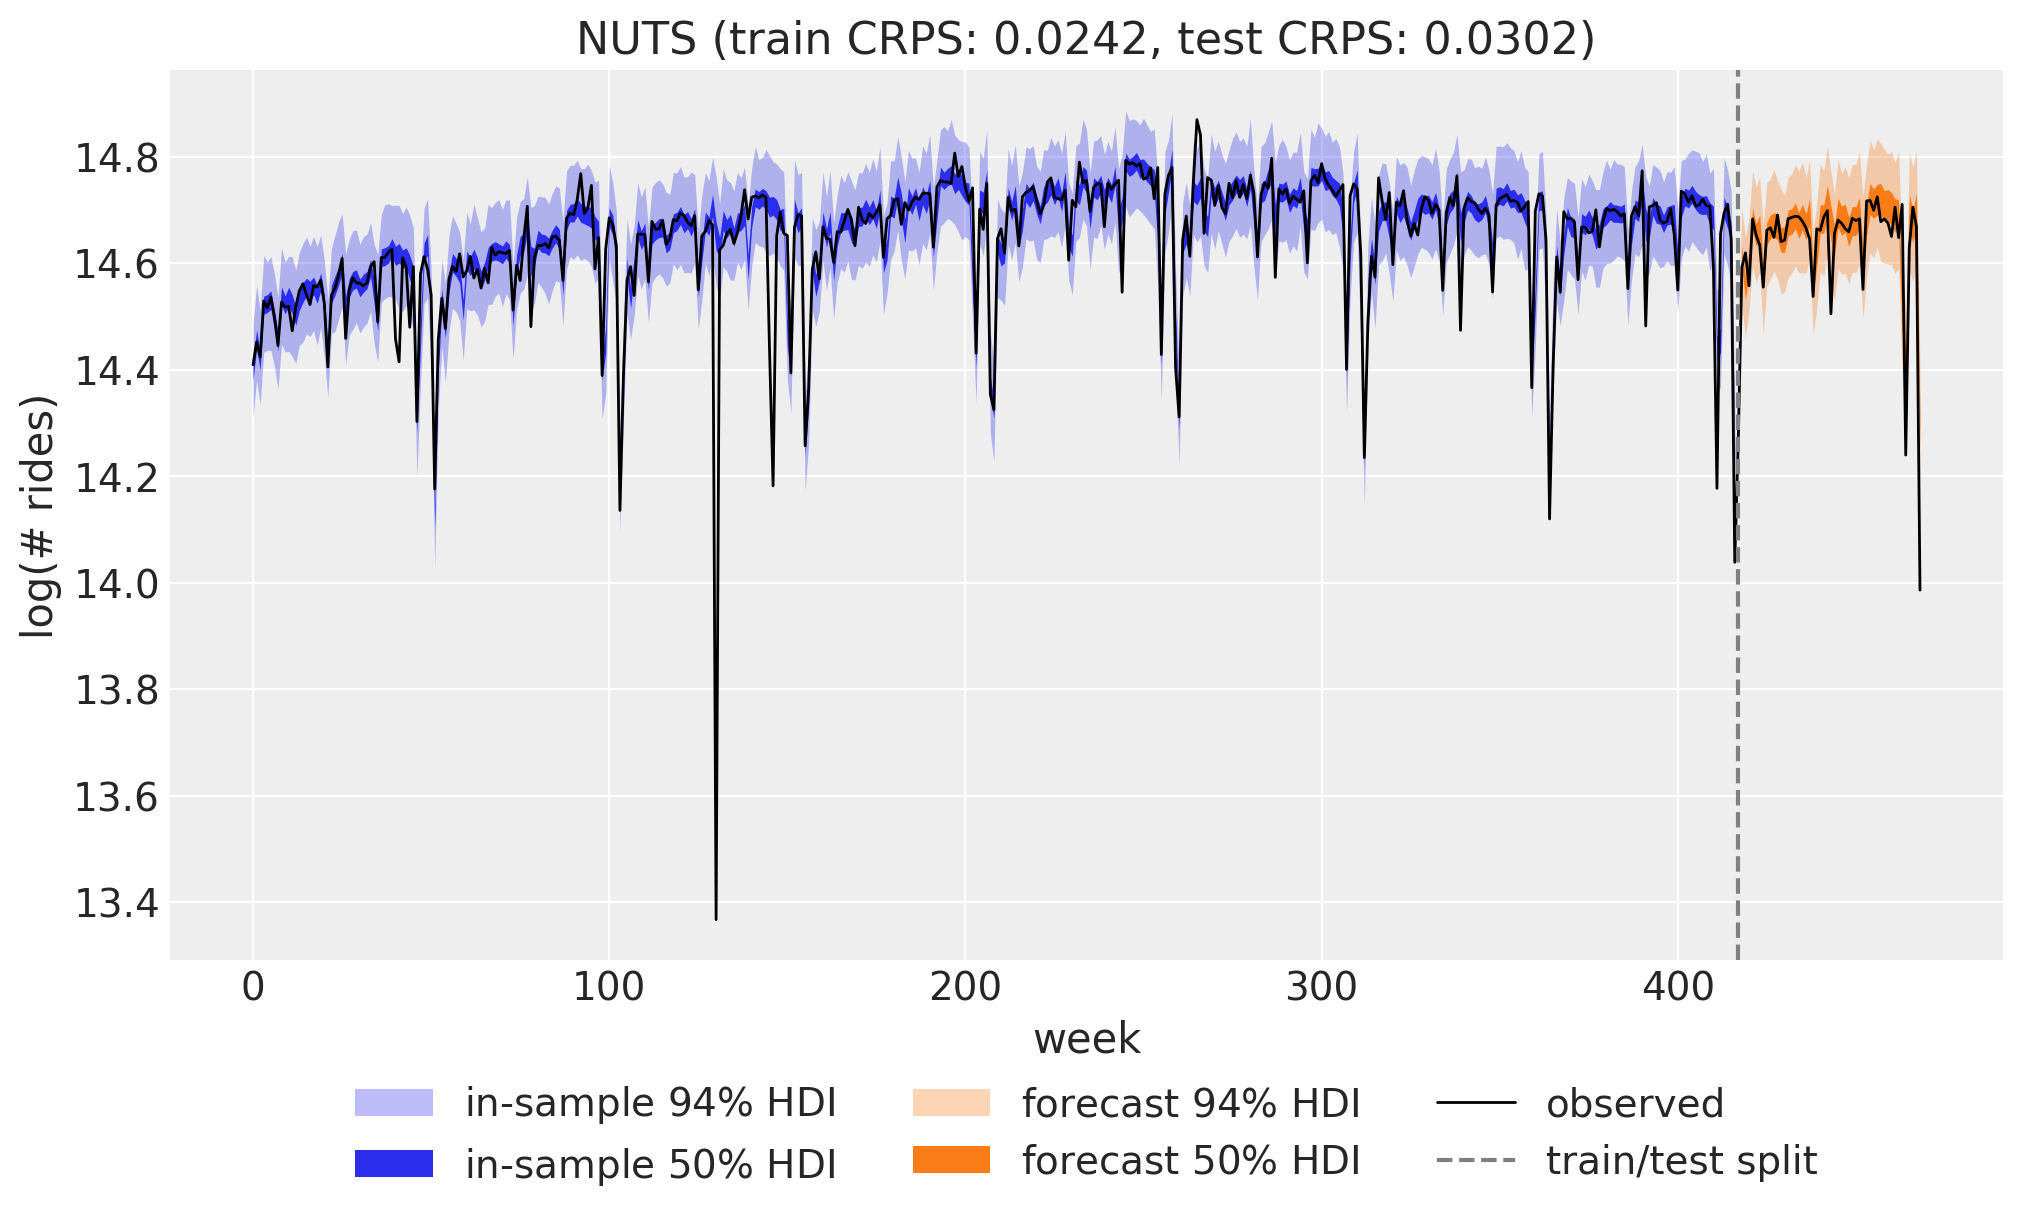

In [21]:
def crps_title(name: str) -> str:
    """Format a plot title with the method's train and test CRPS."""
    scores = crps_results[name]
    return f"{name} (train CRPS: {scores['train']:.4f}, test CRPS: {scores['test']:.4f})"


def plot_forecast(tree: xr.DataTree, title: str) -> None:
    """Overlay the in-sample and forecast HDI bands on the observed series."""
    pc = az.plot_lm(
        tree,
        y="obs",
        x="week",
        group="posterior_predictive",
        ci_kind="hdi",
        ci_prob=(0.5, 0.94),
        smooth=False,
        visuals={"ci_band": {"color": "C0"}, "observed_scatter": False, "pe_line": False},
        figure_kwargs={"figsize": (10, 6)},
    )
    train_bands = pc.viz["ci_band"]["week"]
    band_train_94 = train_bands.sel(prob=0.94).item()
    band_train_50 = train_bands.sel(prob=0.5).item()
    az.plot_lm(
        tree,
        y="obs",
        x="week",
        group="predictions",
        plot_collection=pc,
        ci_kind="hdi",
        ci_prob=(0.5, 0.94),
        smooth=False,
        visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
    )
    test_bands = pc.viz["ci_band"]["week"]
    band_test_94 = test_bands.sel(prob=0.94).item()
    band_test_50 = test_bands.sel(prob=0.5).item()
    ax = pc.viz["figure"].item().axes[0]
    band_train_94.set_label(r"in-sample $94\%$ HDI")
    band_train_50.set_label(r"in-sample $50\%$ HDI")
    band_test_94.set_label(r"forecast $94\%$ HDI")
    band_test_50.set_label(r"forecast $50\%$ HDI")
    (obs_line,) = ax.plot(time, np.asarray(data[:, 0]), color="black", lw=1, label="observed")
    split_line = ax.axvline(T1, color="gray", ls="--", label="train/test split")
    ax.legend(
        handles=[band_train_94, band_train_50, band_test_94, band_test_50, obs_line, split_line],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.1),
        ncol=3,
    )
    ax.set(title=title, ylabel="log(# rides)")


plot_forecast(nuts_tree, title=crps_title("NUTS"))

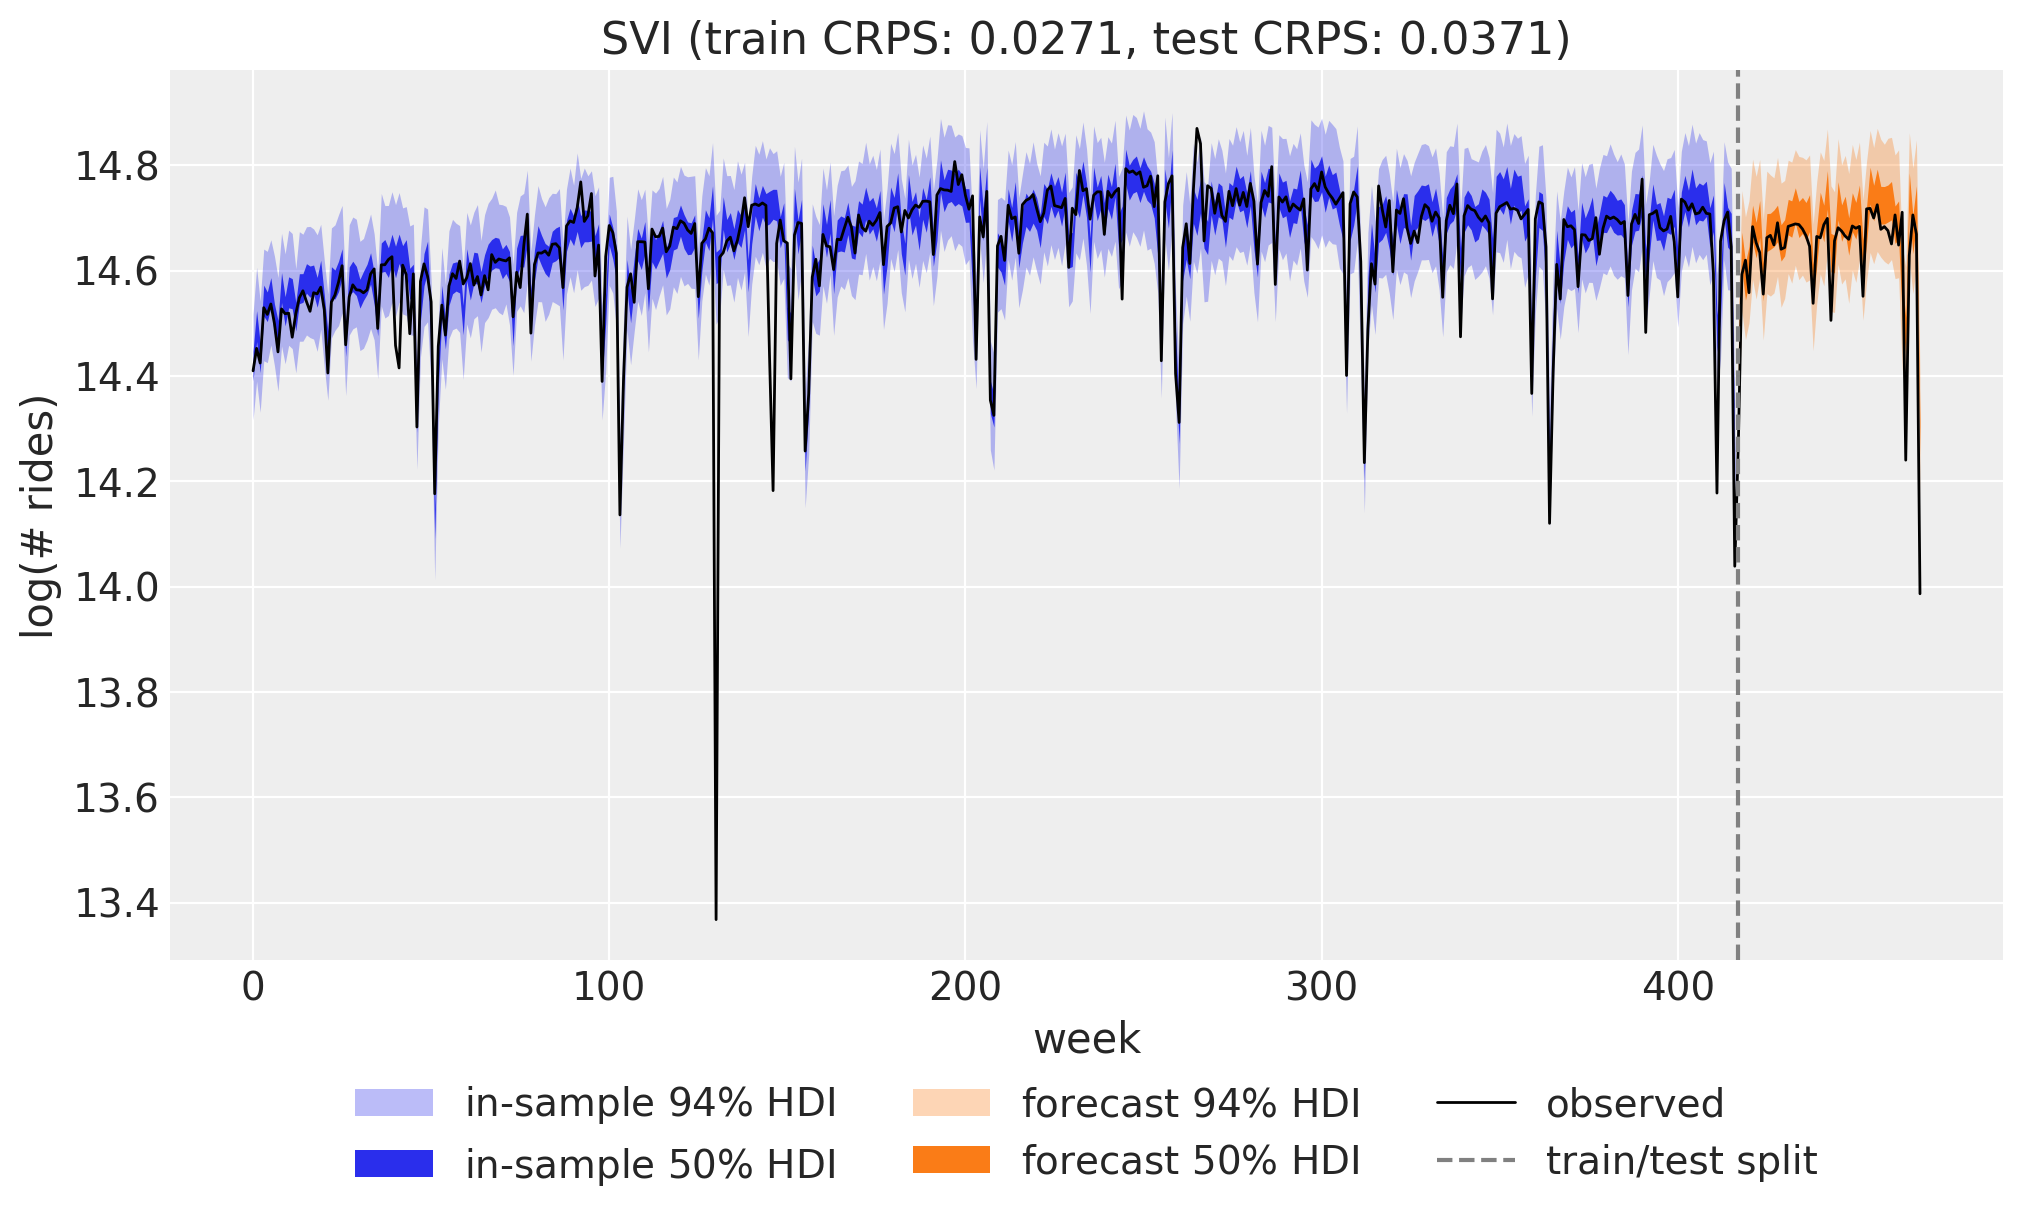

In [22]:
plot_forecast(svi_tree, title=crps_title("SVI"))

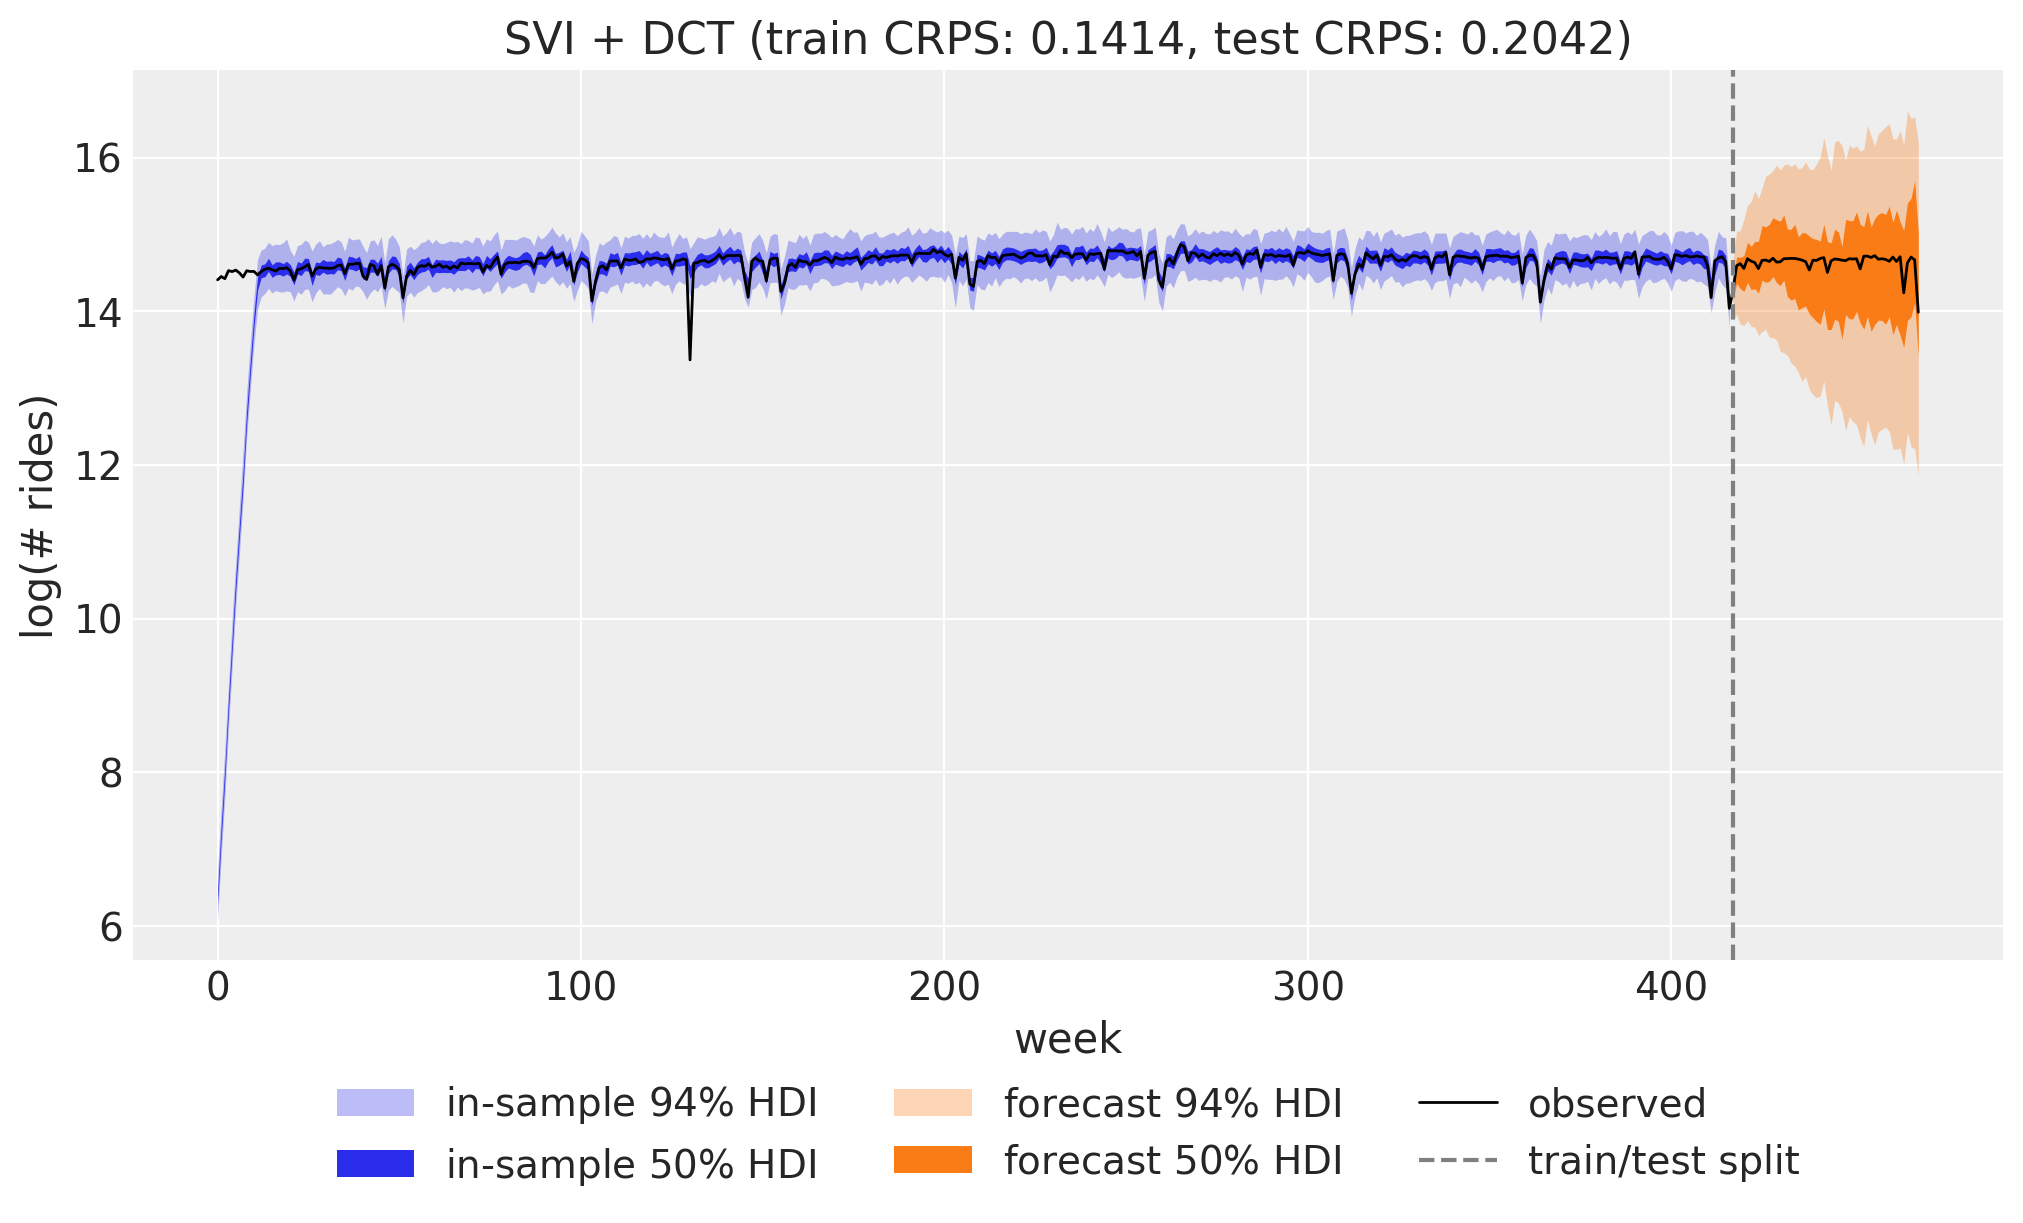

In [23]:
plot_forecast(svi_dct_tree, title=crps_title("SVI + DCT"))

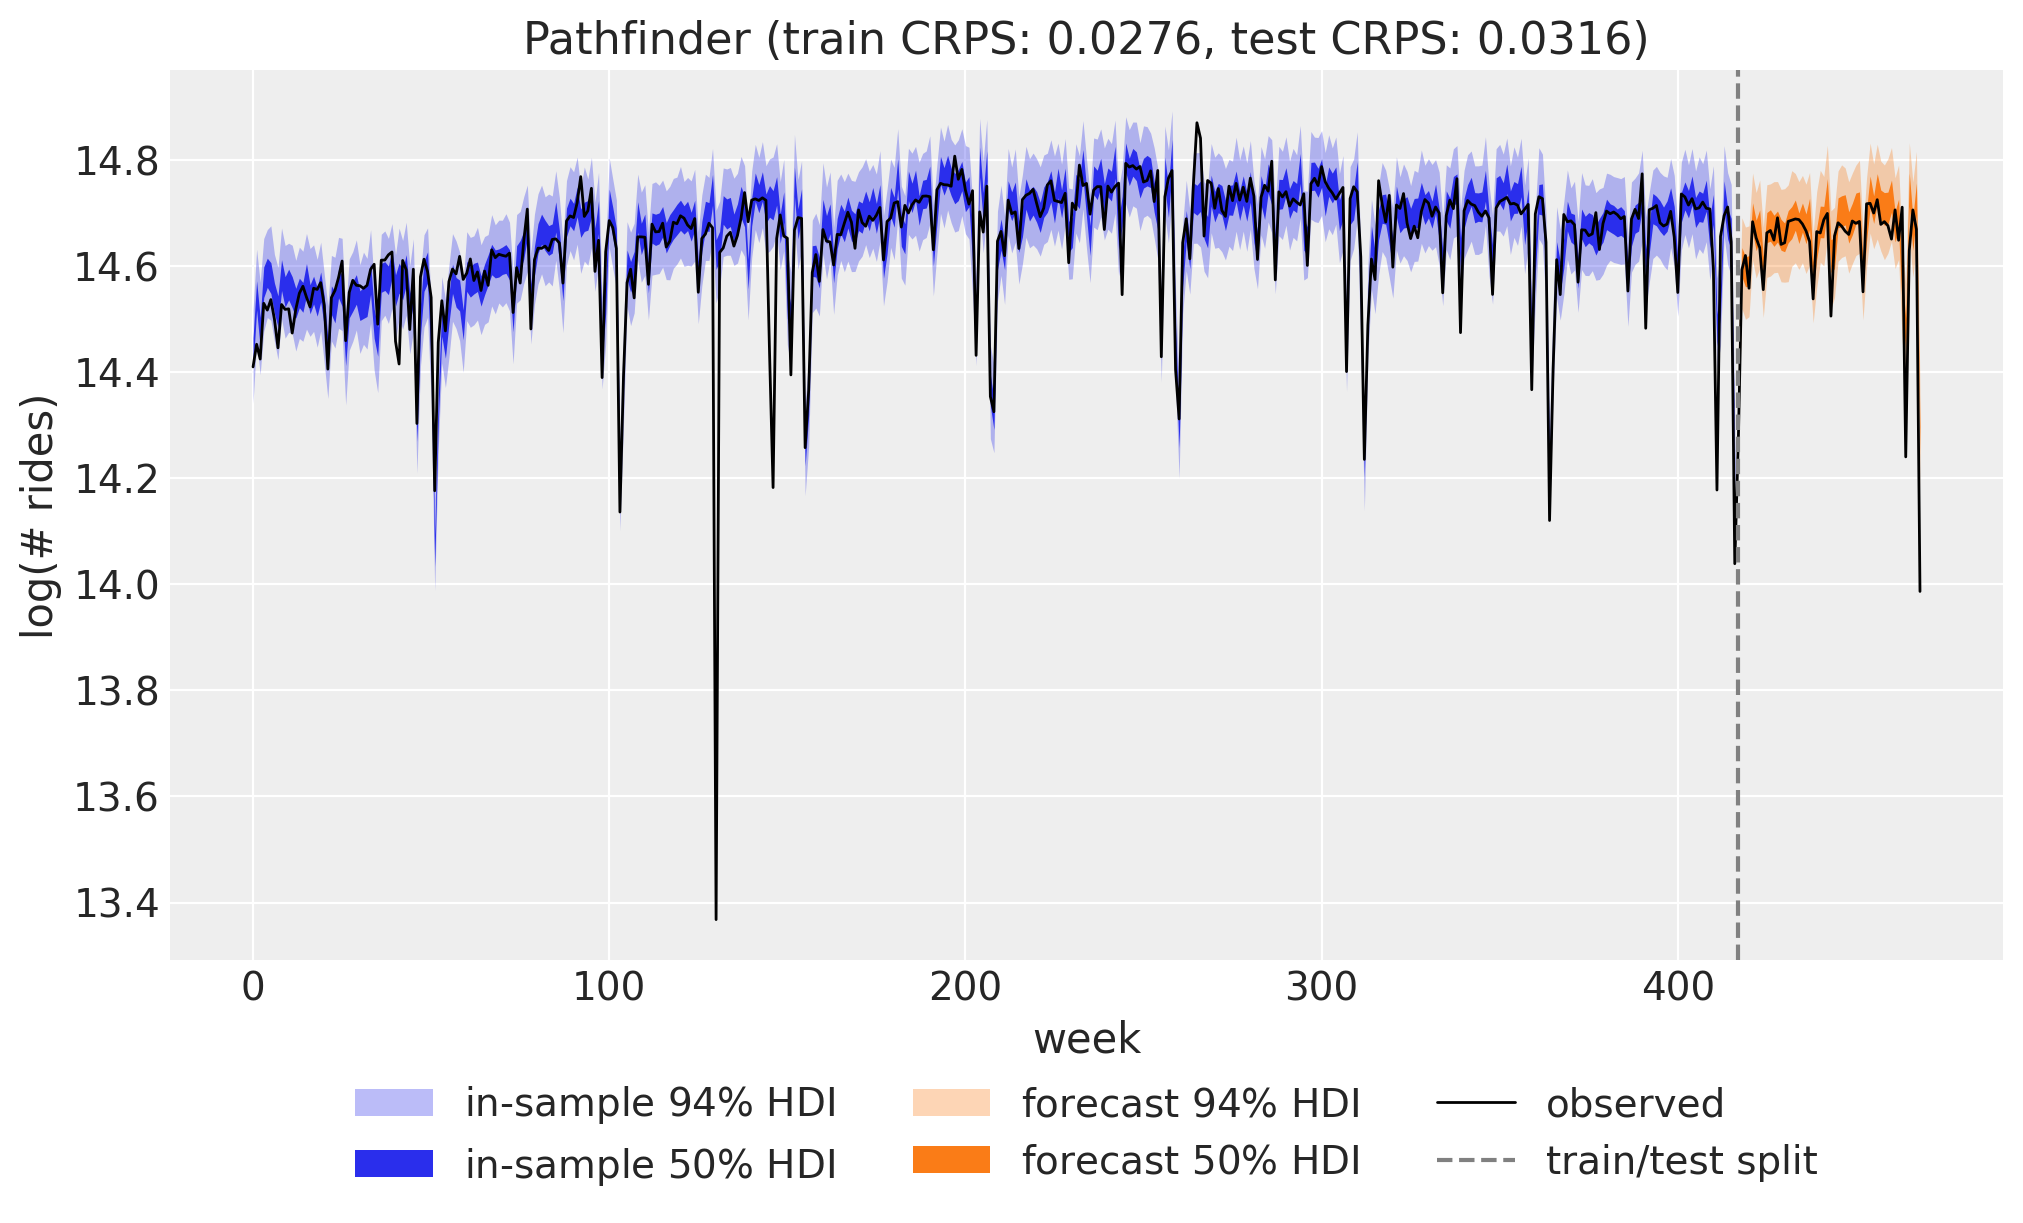

In [24]:
plot_forecast(pathfinder_tree, title=crps_title("Pathfinder"))

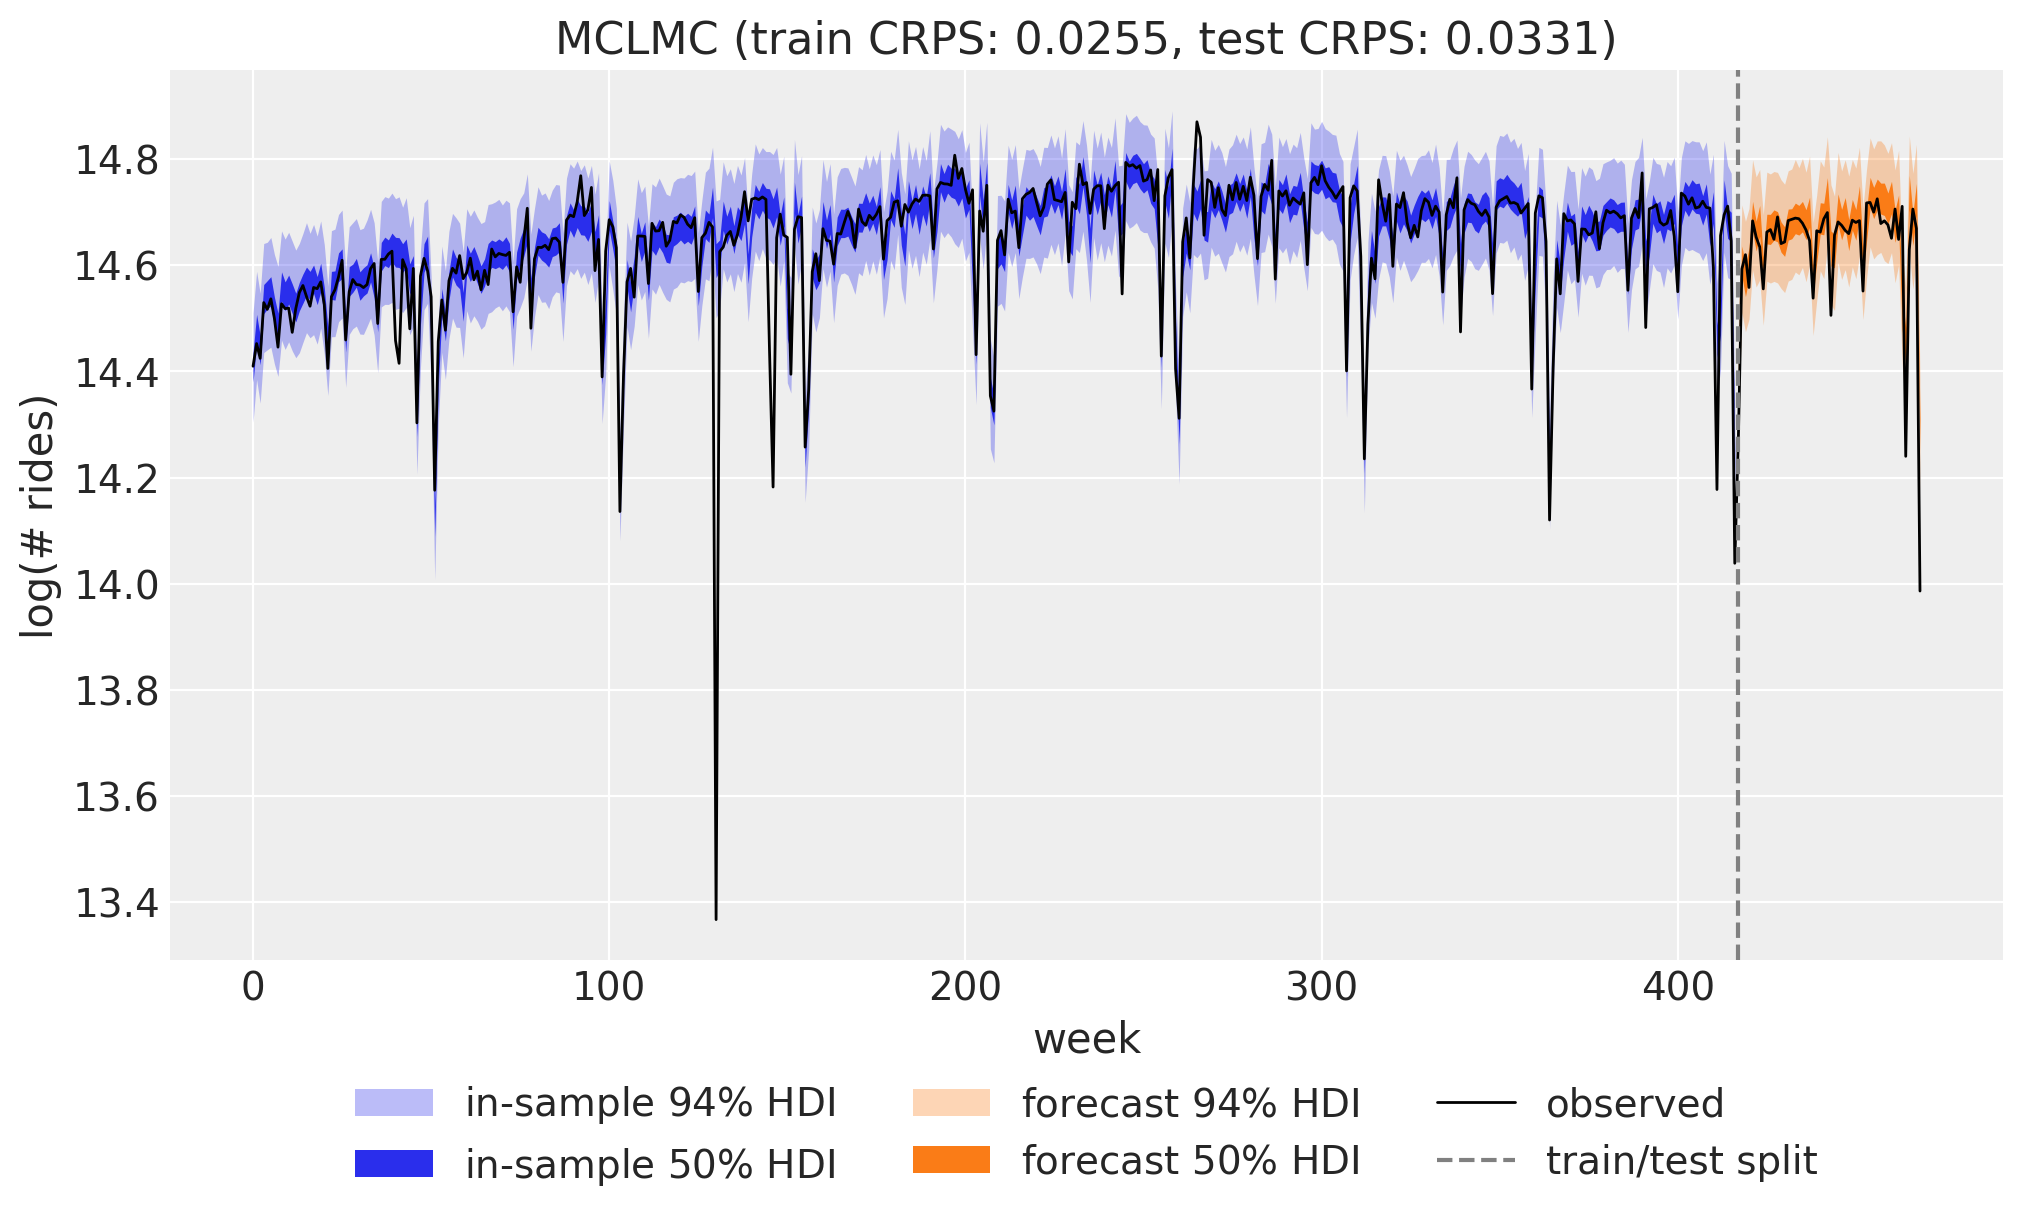

In [25]:
plot_forecast(mclmc_tree, title=crps_title("MCLMC"))

## Trade-offs

The summary plot puts the four engines side by side, together with the two runs that fit the same model through the DCT time-axis reparameterization.

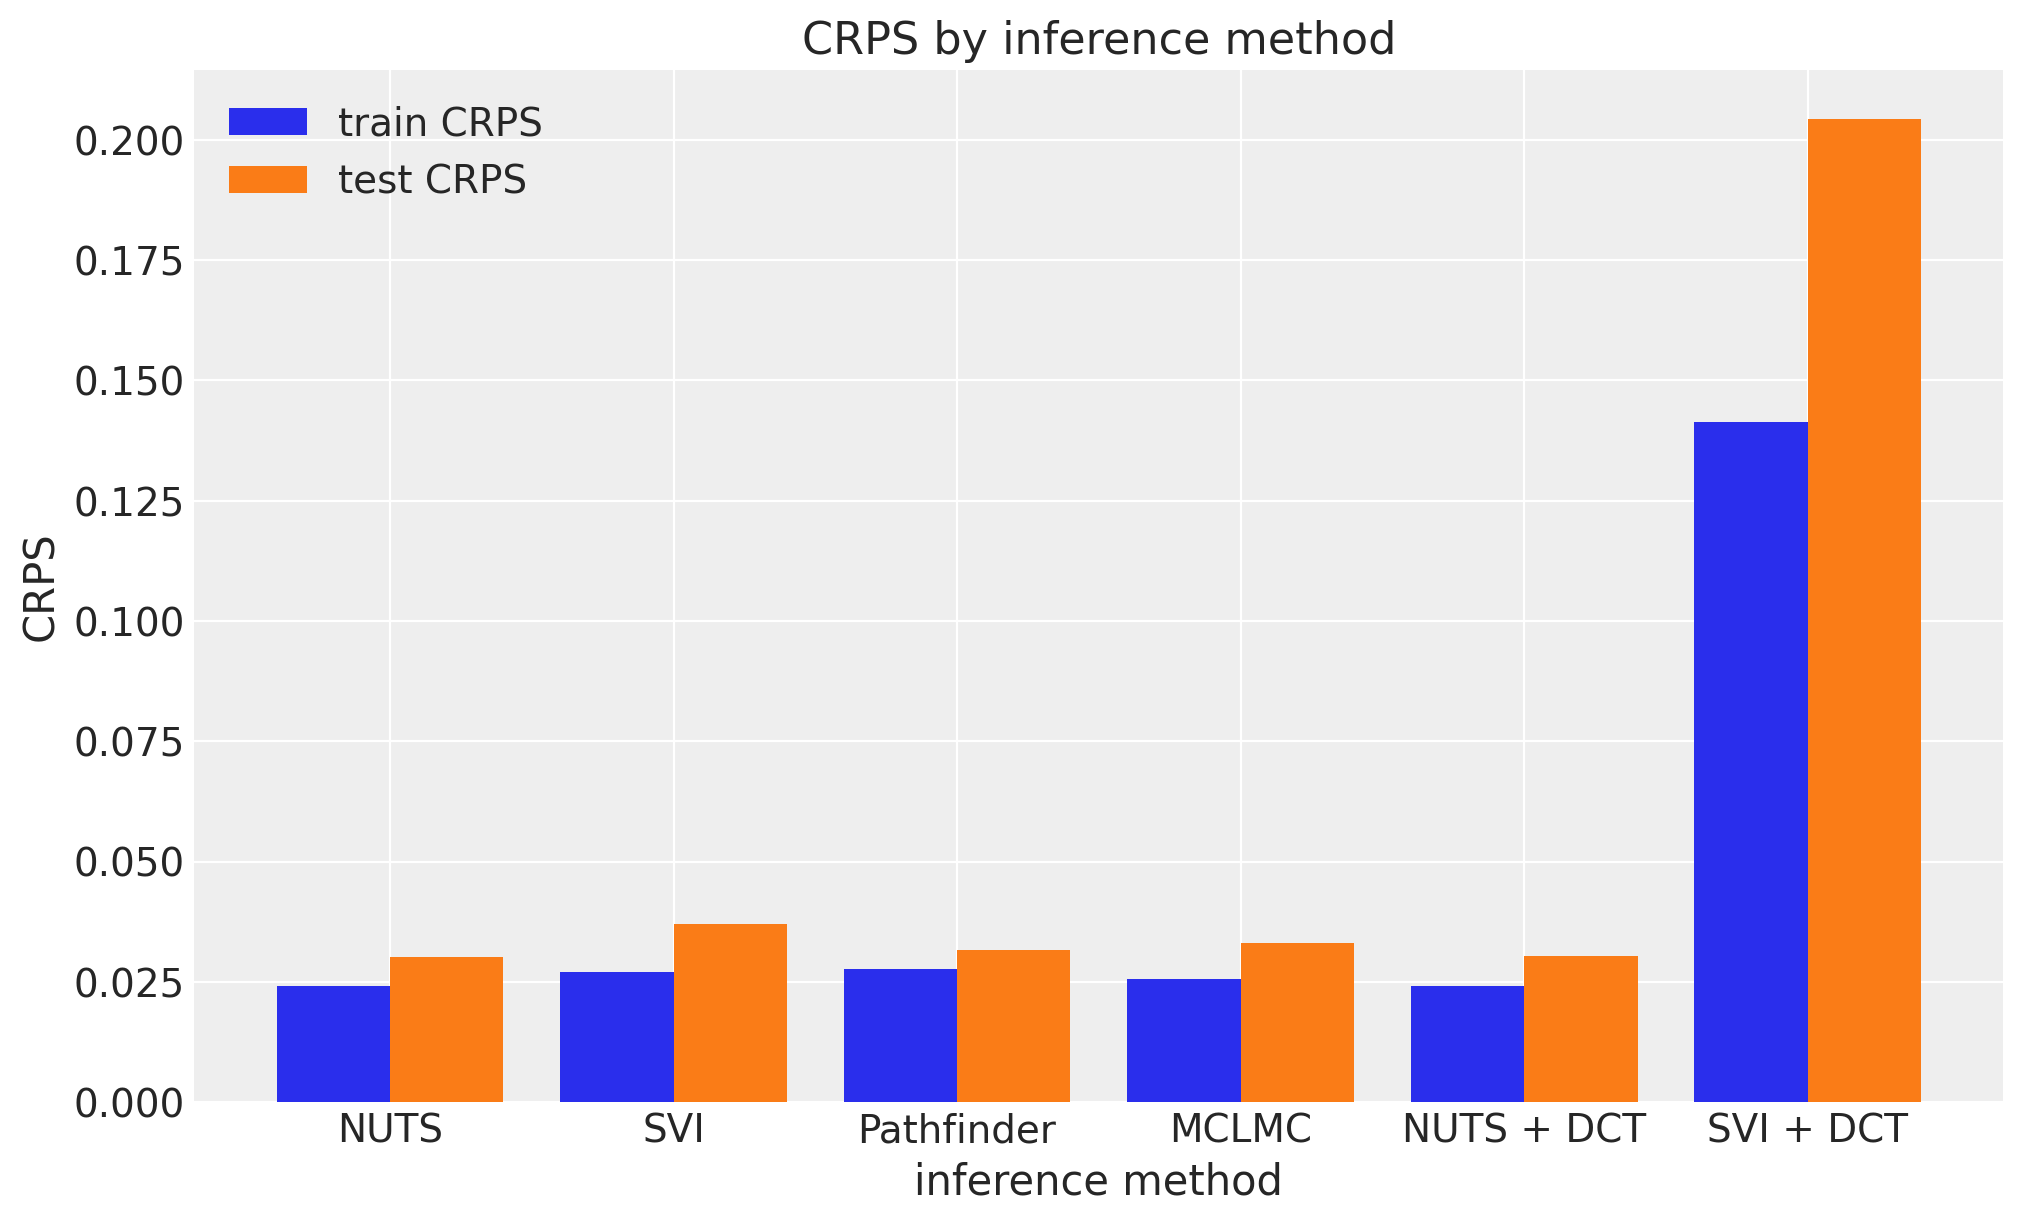

In [26]:
methods = list(crps_results)
train_scores = [crps_results[m]["train"] for m in methods]
test_scores = [crps_results[m]["test"] for m in methods]

x = np.arange(len(methods))
fig, ax = plt.subplots()
ax.bar(x - 0.2, train_scores, width=0.4, color="C0", label="train CRPS")
ax.bar(x + 0.2, test_scores, width=0.4, color="C1", label="test CRPS")
ax.set_xticks(x, methods)
ax.legend()
ax.set(title="CRPS by inference method", xlabel="inference method", ylabel="CRPS");

NUTS sets the reference score on both windows (train CRPS `0.0242`, test CRPS `0.0302`) in `40.7`s across its `4` chains. MCLMC (`5.4`s) and SVI (`5.2`s) both track that reference closely at a small fraction of the cost: MCLMC's `0.0255`/`0.0331` train/test CRPS comes from spending two fixed gradient evaluations per draw instead of a full NUTS trajectory, though its silent-failure mode still deserves the validation that NUTS's divergence diagnostics provide for free, and SVI's `0.0271`/`0.0371` reflects a diagonal-Gaussian guide that cannot bend to the true posterior's shape as faithfully as sampling does.

Multi-path Pathfinder is the interesting case, because its forecasts and its own diagnostic point in opposite directions. Its scores are close to the reference, `0.0276` train and `0.0316` test CRPS, the second-best test score in the table, while its `pareto_k` came out at `12.35`, more than an order of magnitude above the `0.7` reliability threshold. Both readings are correct, because they describe different objects. The `pareto_k` printed by the fit cell measures whether importance weights over the pooled per-path draws can be trusted, and on a `474`-parameter posterior they cannot: the log ratio between the target and the approximation is dominated by a handful of draws. The samples that produced the CRPS above never passed through those weights, because `resample="auto"` read the same `pareto_k`, fell back to ELBO-weighted path sampling, and let the best path take over.

The cost side is less flattering. At `79.9`s for `8` paths, Pathfinder is the slowest fit in the notebook, slower than NUTS's `40.7`s, because the ELBO is estimated at every one of the `500` L-BFGS iterates of all `8` paths. Most of that budget buys the diversity that makes the ELBO comparison meaningful rather than accuracy as such: fewer paths, or a smaller `maxiter`, would be much cheaper at the price of not knowing whether any path had converged. Read the table together with the diagnostic rather than either alone. Pathfinder here is an accurate, well-diagnosed fit that is not yet a cheap one, and tuning it down toward its usual role, a fast approximate posterior or an MCMC initializer, is the obvious next experiment.

The two DCT columns show what `time_reparam` does and does not change. NUTS + DCT reproduces the NUTS scores exactly (`0.0242`/`0.0303`), as it must for a unit-Jacobian change of coordinates, and it changes the sampler's work: `314` leapfrog steps per draw instead of `446` and a minimum bulk ESS over the drift increments of `559` instead of `46`, a twelvefold gain per draw, at `56.9`s against `40.7`s of wall time because each leapfrog step now pays for the transform. Per effective sample it is by far the cheapest MCMC run in the notebook. SVI + DCT is the cautionary column: with the one-cycle schedule tuned for the original coordinates it lands in the worse basin diagnosed above (final ELBO loss `197` against `-436`) and its CRPS of `0.1414`/`0.2042` is the worst in the table, while the same reparameterization under a fixed `Adam(0.005)` for `50_000` steps ends at the better ELBO in the univariate example. The rotation is free for the model and for the sampler; for a variational fit it is a change of optimization problem whose schedule has to be re-tuned.

## Next steps

A single train/test split is only one view of forecasting skill; the [univariate example](forecasting_univariate.html) shows how to score these same models with rolling-origin backtesting, including a fully vectorized variant. From here you can also swap guides (`AutoMultivariateNormal` captures posterior correlations that `AutoNormal` ignores, at the cost of an `O(n^2)` covariance), or swap kernels (`BlackjaxNUTSKernel` runs BlackJAX's own NUTS through the same adapter MCLMC used above, and `BlackjaxCustomKernel` accepts any BlackJAX sampler through a small build function) without touching `univariate_model` or the `to_datatree` export itself.

## References

- Orduz, J. [*Univariate time series forecasting with NumPyro*](https://juanitorduz.github.io/numpyro_forecasting-univariate/).
- Pyro. [*Forecasting I: Univariate, Heavy Tailed*](https://pyro.ai/examples/forecasting_i.html).
- Hoffman, M. D., & Gelman, A. (2014). [*The No-U-Turn Sampler: Adaptively setting path lengths in Hamiltonian Monte Carlo*](https://jmlr.org/papers/v15/hoffman14a.html). JMLR.
- Hoffman, M. D., Blei, D. M., Wang, C., & Paisley, J. (2013). [*Stochastic variational inference*](https://jmlr.org/papers/v14/hoffman13a.html). JMLR.
- Zhang, L., Carpenter, B., Gelman, A., & Vehtari, A. (2022). [*Pathfinder: Parallel quasi-Newton variational inference*](https://jmlr.org/papers/v23/21-0889.html). JMLR.
- Vehtari, A., Simpson, D., Gelman, A., Yao, Y., & Gabry, J. (2024). [*Pareto smoothed importance sampling*](https://jmlr.org/papers/v25/19-556.html). JMLR.
- Robnik, J., De Luca, G. B., Silverstein, E., & Seljak, U. (2023). [*Microcanonical Hamiltonian Monte Carlo*](https://jmlr.org/papers/v24/22-1450.html). JMLR.
- Robnik, J., & Seljak, U. (2024). [*Fluctuation without dissipation: Microcanonical Langevin Monte Carlo*](https://arxiv.org/abs/2303.18221).
- Smith, L. N., & Topin, N. (2019). [*Super-convergence: Very fast training of neural networks using large learning rates*](https://arxiv.org/abs/1708.07120).